In [ ]:
# 1. Install dependensi
!pip install sentence-transformers faiss-cpu scikit-learn -q

import os
import json

# 1. Buat direktori
os.makedirs("project", exist_ok=True)
os.makedirs("project/backups", exist_ok=True)
os.makedirs("project/logs", exist_ok=True)
%cd project

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 24.3 MB/s eta 0:00:00
/content/project


In [ ]:
# 2. Buat faq_data.json (minimal)
faq_data = [

    {
        "intent": "prinsip_syariah",
        "question": "Apa yang membedakan koperasi syariah dengan konvensional?",
        "response": (
            "Pertanyaan yang bagus! Koperasi Syariah beroperasi berdasarkan prinsip Islam: \n"
            "✅ Tidak ada **riba (bunga)**\n"
            "✅ Tidak ada **denda keterlambatan** (diganti dengan komitmen fee yang disepakati)\n"
            "✅ Transparan dan adil dalam akad\n"
            "✅ Dana dihimpun dan disalurkan secara halal\n"
            "✅ Dikelola dengan nilai kekeluargaan dan tolong-menolong (ta'awun)\n\n"
            "Kami juga memiliki Dewan Pengawas Syariah yang memastikan semua proses sesuai dengan fatwa DSN-MUI. InsyaAllah amanah dan barokah."
        ),
        "variations": [
            "bedanya dengan bank konvensional?",
            "apa benar tanpa bunga?",
            "ada denda kalau telat bayar?",
            "bagaimana sistem bagi hasil?",
            "siapa yang mengawasi secara syariah?"
            "prinsip koperasi syariah"
        ]
    },
    {
        "intent": "akad_pembiayaan",
        "question": "Apa itu akad dalam pembiayaan syariah?",
        "response": (
            "Akad adalah perjanjian sah secara syariah antara anggota dan koperasi. "
            "Contohnya:\n"
            "🔹 **Murabahah**: jual beli dengan harga markup yang disepakati (untuk pembelian barang)\n"
            "🔹 **Qardhul Hasan**: pinjaman baik tanpa bunga, hanya kembalikan pokok\n"
            "🔹 **Ijarah**: sewa menyewa aset\n\n"
            "Setiap pengajuan akan dibuatkan akad digital yang bisa Bapak/Ibu simpan. Semua akad sudah sesuai fatwa DSN-MUI dan tidak mengandung unsur gharar atau riba."
        ),
        "variations": [
            "apa itu akad murabahah?",
            "perjanjian syariah seperti apa?",
            "harus tanda tangan fisik?",
            "akad online sah tidak?",
            "bisa lihat contoh akadnya?"
            "apa saja jenis pinjaman"
            "apa saja jenis pembiayaan"
        ]
    },


    # --- 🔹 INTENT BARU: Sapaan Awal ---
    {
        "intent": "sapaan_awal",
        "question": "Halo",
        "response": (
            "Assalamu’alaikum warahmatullahi wabarakatuh 🌿\n\n"
            "Selamat datang di layanan chatbot **Koperasi Syariah ALMUHAJIR**! Saya SIBOTAK, asisten digital Anda.\n\n"
            "Ada yang bisa saya bantu hari ini? Misalnya:\n"
            "🔹 Ajukan pembiayaan tanpa bunga\n"
            "🔹 Cek status pengajuan\n"
            "🔹 Info cicilan atau tabungan\n"
            "🔹 Atau sekadar tanya prinsip syariah\n\n"
            "Silakan ketik kebutuhan Anda, saya siap membantu dengan ramah dan cepat. InsyaAllah!"
        ),
        "variations": [
            "hai",
            "halo",
            "assalamualaikum",
            "pagi, ada yang bisa dibantu?",
            "help",
            "mulai",
            "start",
            "assist",
            "hi",
            "selamat siang"
        ]
    },

    # --- 🔹 INTENT BARU: Penutup Percakapan ---
    {
        "intent": "ucapan_selamat_tinggal",
        "question": "Terima kasih, sampai jumpa!",
        "response": (
            "Wa’alaikumsalam warahmatullah 🌸\n\n"
            "Terima kasih atas kepercayaan Bapak/Ibu kepada Koperasi Syariah Amanah. \n"
            "Semoga segala urusan dimudahkan, rezeki berkah, dan usaha semakin maju. Aamiin.\n\n"
            "Jika nanti butuh bantuan lagi, saya selalu siap di sini. Sampai jumpa lagi, semoga hari Bapak/Ibu penuh kebaikan dan barokah. 🤲"
        ),
        "variations": [
            "terima kasih",
            "makasih",
            "thanks",
            "sampai jumpa",
            "bye",
            "selesai",
            "oke, sudah selesai",
            "gak ada lagi",
            "tutup percakapan",
            "keluar"
        ]
    },
    {
        "intent": "pertanyaan riba",
        "question": "apa itu riba",
        "response": (
            "Riba adalah penambahan yang tidak sah atau keuntungan berlebih yang terjadi dalam transaksi keuangan, baik dalam jual beli maupun utang-piutang, yang merugikan salah satu pihak dan dilarang dalam Islam karena bertentangan dengan prinsip keadilan dan kesejahteraan ekonomi. Riba memiliki dua jenis utama, yaitu Riba al-Fadl (pertukaran barang sejenis dengan kelebihan) dan Riba al-Nasi\'ah (tambahan pada utang yang pembayarannya ditunda)"
        ),
        "variations": [
            "riba?",
            "Pinjaman dengan bunga",
        ]
    },
      {
    "intent": "definisi_koperasi_syariah",
    "question": "Apa itu Koperasi Syariah menurut DSN-MUI?",
    "response": "Koperasi Syariah adalah koperasi yang didirikan, dikelola, dan menjalankan kegiatan usaha berdasarkan prinsip syariah Islam. Berdasarkan Fatwa DSN-MUI No. 141, koperasi ini mengedepankan nilai keadilan, amanah, tolong-menolong (ta'awun), serta bebas dari riba, gharar, maysir, dan dharar. Anggotanya sekaligus pemilik sekaligus pengguna jasa.",
    "variations": [
      "pengertian koperasi syariah",
      "arti koperasi syariah menurut mui",
      "apa bedanya dengan koperasi biasa?",
      "koperasi islam itu seperti apa?",
      "apa dasar hukum koperasi syariah?"
    ]
  },
  {
    "intent": "dasar_hukum",
    "question": "Apa dasar hukum pendirian Koperasi Syariah?",
    "response": "Dasar hukumnya terdiri dari Al-Qur'an (seperti QS. Al-Baqarah:275 tentang larangan riba), hadis Nabi SAW, kaidah fikih (misal: 'Al-ashlu fi al-muamalat al-ibahah'), serta Fatwa DSN-MUI No. 141/DSN-MUI/VII/2021. Selain itu, harus sesuai dengan peraturan perundang-undangan yang berlaku di Indonesia.",
    "variations": [
      "dasar hukum koperasi syariah",
      "dari mana aturan koperasi syariah?",
      "apakah koperasi syariah legal secara negara?",
      "fatwa mui no 141 itu tentang apa?",
      "mengapa koperasi syariah harus ikut dsn-mui?"
    ]
  },
  {
    "intent": "pendirian_koperasi",
    "question": "Bagaimana cara mendirikan Koperasi Syariah?",
    "response": "Untuk mendirikan Koperasi Syariah, para anggota melakukan akad Syirkah 'Inan (kerja sama modal). Modal bisa berupa uang atau barang yang dinilai terlebih dahulu. Pengelolaan diserahkan kepada pengurus melalui wakalah dalam Rapat Anggota. Harus ada Dewan Pengawas Syariah (DPS) dan mematuhi prinsip syariah dalam semua operasionalnya.",
    "variations": [
      "cara bikin koperasi syariah",
      "syarat buka koperasi syariah",
      "proses pendirian koperasi syariah",
      "haruskah punya dps?",
      "bisakah tanpa fatwa mui?"
    ]
  },
  {
    "intent": "struktur_kelembagaan",
    "question": "Siapa saja struktur organisasi Koperasi Syariah?",
    "response": "Struktur utama terdiri dari: Anggota, Pengurus, Pengawas, dan Dewan Pengawas Syariah (DPS). Anggota adalah pemilik sekaligus pengguna jasa. Pengurus mengelola usaha, Pengawas mengawasi kinerja, sedangkan DPS mengawasi kepatuhan terhadap prinsip syariah. Semua dipilih dalam Rapat Anggota.",
    "variations": [
      "siapa yang mengelola koperasi syariah?",
      "tugas dewan pengawas syariah",
      "perbedaan pengawas dan dps",
      "anggota punya hak apa saja?",
      "bagaimana pemilihan pengurus?"
    ]
  },
  {
    "intent": "modal_sendiri",
    "question": "Apa saja sumber modal sendiri Koperasi Syariah?",
    "response": "Modal sendiri (ekuitas) terdiri dari: Simpanan Pokok dan Wajib (akad Syirkah), Dana Cadangan (dari SHU setelah zakat & pajak), Hibah (akad Hibah), Manfaat Wakaf (koperasi sebagai nazhir), dan sumber halal lainnya. Semua menjadi bagian dari dana syirkah permanen.",
    "variations": [
      "sumber ekuitas koperasi syariah",
      "dana cadangan itu dari mana?",
      "simpanan pokok boleh ditarik?",
      "koperasi bisa terima wakaf?",
      "apa itu dana syirkah permanen?"
    ]
  },
  {
    "intent": "modal_luar",
    "question": "Bagaimana koperasi menghimpun modal dari luar?",
    "response": "Modal dari luar bisa berasal dari: simpanan (akad Wadi’ah atau Mudharabah), dana talangan (akad Qardh), pembiayaan dari lembaga lain (Musyarakah/Mudharabah), atau modal penyertaan temporer (Wakalah bi al-Istitsmar). Semua harus sesuai prinsip syariah dan tidak mengandung riba.",
    "variations": [
      "pinjaman dari luar boleh tidak?",
      "modal penyertaan artinya apa?",
      "bisa terima deposito syariah?",
      "bedanya wadi’ah dan mudharabah?",
      "dana talangan itu seperti apa?"
    ]
  },
  {
    "intent": "akad_utama",
    "question": "Akad apa saja yang digunakan dalam Koperasi Syariah?",
    "response": "Beberapa akad utama antara lain: Syirkah 'Inan (kerja sama modal), Murabahah (jual beli untung), Salam (pemesanan bayar dimuka), Ijarah (sewa), Qardhul Hasan (pinjaman baik), Mudharabah (bagi hasil), Wakalah (wewenang), Rahn (jaminan), dan Wakaf. Setiap transaksi harus menggunakan akad yang sah secara syariah.",
    "variations": [
      "daftar akad koperasi syariah",
      "akad untuk pinjaman tanpa bunga",
      "jual beli syariah pakai akad apa?",
      "apa itu akad ijarah muntahiyyah?",
      "bolehkah pakai akad gharar?"
    ]
  },
  {
    "intent": "simpanan_pokok_wajib",
    "question": "Apa perbedaan Simpanan Pokok dan Simpanan Wajib?",
    "response": "Simpanan Pokok adalah jumlah tetap yang dibayar saat menjadi anggota dan tidak bisa ditarik selama masih aktif. Simpanan Wajib adalah jumlah berkala (misal bulanan) yang juga tidak bisa ditarik. Keduanya menggunakan akad Syirkah dan menjadi bagian dari ekuitas koperasi.",
    "variations": [
      "simpanan pokok boleh dicairkan?",
      "harus bayar tiap bulan?",
      "kalau keluar apakah dapat uangnya?",
      "jumlah simpanan pokok standar?",
      "simpanan wajib masuk shu?"
    ]
  },
  {
    "intent": "pembiayaan_multijasa_refinancing",
    "question": "Apa itu Pembiayaan Multijasa dan Refinancing?",
    "response": "Pembiayaan Multijasa adalah fasilitas untuk memperoleh manfaat barang/jasa tertentu (misal: kendaraan, modal usaha). Sedangkan Refinancing adalah penyediaan pembiayaan baru bagi nasabah yang belum lunas, asalkan memenuhi analisis kemampuan bayar dan ketentuan syariah.",
    "variations": [
      "pinjaman untuk beli motor",
      "bisa ajukan lagi sebelum lunas?",
      "refinancing itu seperti apa?",
      "ada pinjaman multiguna syariah?",
      "boleh refinancing tanpa agunan?"
    ]
  },
  {
    "intent": "shu_zakat",
    "question": "Bagaimana pembagian SHU dan kewajiban zakat?",
    "response": "Sisa Hasil Usaha (SHU) dibagi setelah dikurangi biaya operasional, dana cadangan, zakat, dan pajak. Pembagian sesuai kesepakatan anggota, biasanya berdasarkan transaksi dan simpanan. Zakat wajib dibayar jika memenuhi nisab dan haul, baik atas laba maupun simpanan berbasis Mudharabah.",
    "variations": [
      "shu koperasi dibagi seperti apa?",
      "haruskah bayar zakat?",
      "zakat atas simpanan?",
      "kapan shu dibagikan?",
      "apakah shu kena pajak?"
    ]
  },
  {
    "intent": "kegiatan_sosial",
    "question": "Apakah Koperasi Syariah bisa menyalurkan zakat dan wakaf?",
    "response": "Ya, koperasi boleh menerima dan menyalurkan zakat, infaq, shadaqah, dan wakaf. Dana sosial ini dikelola secara terpisah dan transparan. Koperasi juga bisa menjadi nazhir wakaf, memanfaatkan hasil wakaf untuk penguatan modal atau program sosial, namun harta pokok wakaf tidak boleh dikonsumsi.",
    "variations": [
      "bisa terima wakaf uang?",
      "salurkan zakat untuk apa saja?",
      "koperasi sebagai nazhir wakaf",
      "program sosial koperasi",
      "qardhul hasan untuk siapa?"
    ]
  },
  {
    "intent": "penyelesaian_sengketa",
    "question": "Bagaimana penyelesaian sengketa di Koperasi Syariah?",
    "response": "Penyelesaian sengketa harus dimulai dengan musyawarah mufakat. Jika tidak berhasil, dapat dilanjutkan ke Badan Arbitrase Syariah Nasional (BASYARNAS) atau Pengadilan Agama. Proses harus sesuai prinsip syariah dan peraturan perundang-undangan yang berlaku.",
    "variations": [
      "kalau ada konflik dengan pengurus?",
      "bisa lapor ke basyarnas?",
      "musyawarah itu wajib?",
      "gugat ke pengadilan agama?",
      "apa itu basyarnas?"
    ]
  },
  {
    "intent": "tanggung_jawab_anggota",
    "question": "Apakah anggota bertanggung jawab atas utang koperasi?",
    "response": "Tidak. Tanggung jawab anggota terbatas pada jumlah simpanan pokok dan wajib yang dimiliki. Anggota tidak bertanggung jawab secara pribadi atas utang koperasi yang melebihi simpanannya. Namun, jika kerugian disebabkan oleh kelalaian pengurus, maka pengurus bertanggung jawab secara bersama (tanggung renteng).",
    "variations": [
      "kalau koperasi bangkrut?",
      "apakah saya harus bayar utang koperasi?",
      "resiko jadi anggota",
      "pengurus salah urus siapa tanggung?",
      "perlindungan untuk anggota"
    ]
  },
  {
    "intent": "transaksi_elektronik",
    "question": "Apakah akad bisa dilakukan secara digital?",
    "response": "Ya, akad bisa dilakukan secara elektronik (e-signature, aplikasi, dll) selama ada persetujuan kedua belah pihak, data bisa diverifikasi, dan sistem memenuhi ketentuan Fatwa DSN-MUI No. 116 dan 117 tentang layanan berbasis teknologi informasi. Transaksi elektronik sah secara syariah dan hukum positif.",
    "variations": [
      "tanda tangan digital sah?",
      "akad online bisa dipercaya?",
      "pakai aplikasi boleh tidak?",
      "e-koperasi syariah",
      "apakah akad via wa sah?"
    ]
  },
  {
    "intent": "jenis_usaha",
    "question": "Bidang usaha apa saja yang boleh dijalankan?",
    "response": "Koperasi Syariah boleh menjalankan usaha di bidang pertanian, peternakan, perdagangan, industri, keuangan, transportasi, pariwisata, pendidikan, jasa, dan sosial — selama tidak bertentangan dengan prinsip syariah. Bisa single purpose atau multi purpose (serba usaha).",
    "variations": [
      "bisa buka unit usaha ternak?",
      "jual beli online syariah",
      "boleh jalankan bank mini?",
      "usaha apa yang haram?",
      "koperasi bisa buka sekolah?"
    ]
  },
{
    "intent": "nama_dan_tempat_kedudukan",
    "question": "Apa nama dan tempat kedudukan Koperasi Syariah Al Muhajir?",
    "response": "Koperasi ini bernama Koperasi Syariah 'Al Muhajir', disingkat KSAM. Berkedudukan di Margahayu Raya Barat Blok E.II, Kelurahan Sekejati, Kecamatan Buah Batu, Kota Bandung.",
    "variations": [
      "dimana alamat koperasi al muhajir?",
      "koperasi al muhajir di bandung mana?",
      "apa singkatan ksam?",
      "lokasi kantor pusat ksam",
      "alamat resmi ksam"
    ]
  },
  {
    "intent": "visi_misi",
    "question": "Apa visi dan misi Koperasi Syariah Al Muhajir?",
    "response": "Visi: 'Menjadi koperasi syariah sebagai pilar pembangunan ekonomi umat'. Misi: (1) Tingkatkan pendapatan & kesejahteraan anggota, (2) Bangun ketahanan pangan, (3) Galakkan gotong royong, (4) Ciptakan pengusaha muslim tangguh.",
    "variations": [
      "tujuan jangka panjang ksam",
      "misi utama koperasi al muhajir",
      "apa visi ksam?",
      "al muha jir ingin capai apa?",
      "misi koperasi berbasis islami"
    ]
  },
  {
    "intent": "landasan_hukum",
    "question": "Apa landasan hukum Koperasi Syariah Al Muhajir?",
    "response": "Berdasar Pancasila, UUD 1945, dan UU No. 25 Tahun 1992 tentang Perkoperasian. Juga menjunjung azas kekeluargaan dan prinsip syariah dalam seluruh aktivitasnya.",
    "variations": [
      "dasar hukum koperasi al muhajir",
      "berdasarkan pancasila itu maksudnya?",
      "uu perkoperasian no berapa?",
      "apakah legal secara negara?"
    ]
  },
  {
    "intent": "prinsip_koperasi",
    "question": "Apa saja prinsip yang diterapkan oleh Koperasi Syariah Al Muhajir?",
    "response": "Prinsip utama: (1) Keanggotaan sukarela & terbuka, (2) Pengelolaan demokratis, (3) Pembagian SHU adil sesuai kontribusi, (4) Kemandirian. Juga menerapkan pendidikan koperasi & kerjasama antar lembaga.",
    "variations": [
      "prinsip dasar ksam",
      "bagaimana sistem demokrasinya?",
      "shu dibagi seperti apa?",
      "apakah ada pelatihan untuk anggota?"
    ]
  },
  {
    "intent": "fungsi_peran",
    "question": "Apa fungsi dan peran Koperasi Syariah Al Muhajir?",
    "response": "Fungsinya adalah membangun potensi ekonomi anggota, meningkatkan kesejahteraan sosial, serta menjaga keberlanjutan kesejahteraan berbasis syariat Islam. Turut aktif meningkatkan kualitas hidup umat muslim.",
    "variations": [
      "untuk apa sih koperasi ini?",
      "peran ksam bagi masyarakat",
      "bagaimana membantu ekonomi umat?",
      "fokus sosial atau bisnis?"
    ]
  },
  {
    "intent": "tujuan_usaha",
    "question": "Apa tujuan dan usaha yang dilakukan Koperasi Syariah Al Muhajir?",
    "response": "Tujuannya: majukan kesejahteraan anggota & masyarakat muslim, serta bangun perekonomian nasional berdasar Pancasila. Usaha: simpan pinjam syariah, perdagangan eceran, tabungan, kerja sama usaha, dan dukung program pemerintah.",
    "variations": [
      "usaha apa yang dijalankan ksam?",
      "ada pinjaman tanpa bunga?",
      "jual beli juga?",
      "ikut program pemerintah?",
      "bisa nabung di ksam?"
    ]
  },
  {
    "intent": "syarat_keanggotaan",
    "question": "Siapa yang bisa menjadi anggota Koperasi Syariah Al Muhajir?",
    "response": "Warga Negara Indonesia (WNI) yang: (1) Dewasa & mampu bertindak hukum, (2) Berdomisili di Kota Bandung, (3) Bayar simpanan pokok & wajib, (4) Setuju dengan AD/ART dan keputusan rapat anggota.",
    "variations": [
      "siapa boleh jadi anggota?",
      "harus tinggal di bandung?",
      "wajib punya ktp?",
      "bisa daftar online?",
      "butuh rekomendasi?"
    ]
  },
  {
    "intent": "kewajiban_anggota",
    "question": "Apa saja kewajiban anggota Koperasi Syariah Al Muhajir?",
    "response": "Setiap anggota wajib: (1) Taat pada AD/ART dan keputusan rapat, (2) Bayar simpanan pokok & wajib, (3) Ikut aktif dalam kegiatan usaha, (4) Jaga kebersamaan berbasis kekeluargaan, (5) Tanggung kerugian sesuai ketentuan.",
    "variations": [
      "tugas anggota ksam",
      "harus bayar tiap bulan?",
      "kalau tidak ikut kegiatan?",
      "apa konsekuensi melanggar?"
    ]
  },
  {
    "intent": "hak_anggota",
    "question": "Apa saja hak anggota Koperasi Syariah Al Muhajir?",
    "response": "Hak anggota: (1) Hadir & suara di rapat anggota, (2) Pilih/dipilih jadi pengurus/pengawas, (3) Ajukan rapat luar biasa, (4) Sampaikan saran ke pengurus, (5) Manfaatkan layanan koperasi, (6) Dapat bagian SHU sesuai kontribusi.",
    "variations": [
      "apa hak saya sebagai anggota?",
      "bisa pilih pengurus?",
      "boleh usul rapat?",
      "dapatkan shu?",
      "layanan apa saja tersedia?"
    ]
  },
  {
    "intent": "akhir_keanggotaan",
    "question": "Kapan keanggotaan seseorang berakhir?",
    "response": "Keanggotaan berakhir jika: (1) Meninggal dunia, (2) Mengundurkan diri secara tertulis, (3) Diberhentikan karena melanggar kewajiban atau merugikan koperasi.",
    "variations": [
      "cara keluar dari koperasi",
      "diberhentikan karena apa?",
      "bisa resign?",
      "jika sudah tidak aktif?"
    ]
  },
  {
    "intent": "anggota_luar_biasa",
    "question": "Apa itu Anggota Luar Biasa dan apa haknya?",
    "response": "Anggota Luar Biasa adalah WNI yang tidak berdomisili di Bandung, tetapi ingin berpartisipasi. Mereka tidak punya kewajiban penuh seperti anggota biasa, hanya punya hak suara di rapat, tapi tidak bisa memilih atau dipilih jadi pengurus/pengawas.",
    "variations": [
      "bisa jadi anggota walau luar bandung?",
      "apa bedanya anggota biasa dan luar biasa?",
      "luar biasa dapat shu?",
      "hanya bisa voting?"
    ]
  },
  {
    "intent": "rapat_anggota",
    "question": "Bagaimana mekanisme Rapat Anggota di Koperasi Syariah Al Muhajir?",
    "response": "Rapat Anggota adalah pemegang kekuasaan tertinggi. Tiap anggota punya 1 hak suara. Diadakan minimal 1 kali/tahun, paling lambat 6 bulan setelah tutup buku. Harus hadir minimal 50% + 1 dari total anggota agar sah.",
    "variations": [
      "siapa yang punya kuasa tertinggi?",
      "berapa kali rapat dalam setahun?",
      "minimal peserta rapat?",
      "rapat tahunan kapan?"
    ]
  },
  {
    "intent": "pengambilan_keputusan",
    "question": "Bagaimana cara pengambilan keputusan dalam rapat?",
    "response": "Keputusan diambil dengan musyawarah untuk mufakat. Jika tidak tercapai, ditentukan berdasarkan suara terbanyak. Anggota yang tidak hadir dianggap menyetujui hasil mufakat.",
    "variations": [
      "kalau tidak sepakat?",
      "pakai voting?",
      "tidak hadir artinya setuju?",
      "proses musyawarah seperti apa?"
    ]
  },
  {
    "intent": "wewenang_rapat_anggota",
    "question": "Apa saja wewenang Rapat Anggota?",
    "response": "Rapat Anggota berwenang: (1) Tetapkan AD/ART, (2) Tentukan kebijakan umum, (3) Pilih/hapus pengurus & pengawas, (4) Sahkan laporan keuangan, (5) Tetapkan rencana kerja & anggaran, (6) Putuskan pembagian SHU, (7) Putuskan pembubaran koperasi.",
    "variations": [
      "apa yang bisa diputuskan di rapat?",
      "siapa yang angkat pengurus?",
      "laporan keuangan disetujui oleh siapa?",
      "rencana kerja ditentukan oleh?"
    ]
  },
  {
    "intent": "pengurus",
    "question": "Bagaimana cara memilih dan masa jabatan Pengurus?",
    "response": "Pengurus dipilih langsung oleh anggota dalam Rapat Anggota. Masa jabatannya 3 tahun dan bisa dipilih kembali. Calon harus taqwa, jujur, berpengalaman, sudah jadi anggota minimal 1 tahun, dan tidak bermasalah hukum.",
    "variations": [
      "pengurus dipilih oleh siapa?",
      "berapa lama masa jabatan?",
      "syarat jadi pengurus?",
      "bisa dua periode?"
    ]
  },
  {
    "intent": "tugas_pengurus",
    "question": "Apa saja tugas Pengurus Koperasi Syariah Al Muhajir?",
    "response": "Tugas utama pengurus: (1) Memimpin organisasi & usaha, (2) Mewakili koperasi di dalam & luar pengadilan, (3) Selenggarakan rapat anggota, (4) Kelola administrasi, (5) Putuskan penerimaan & pemberhentian anggota, (6) Bertanggung jawab atas kinerja kepada anggota.",
    "variations": [
      "apa yang dilakukan pengurus?",
      "siapa yang urus koperasi sehari-hari?",
      "bisa ambil keputusan sendiri?",
      "bertanggung jawab ke siapa?"
    ]
  },
  {
    "intent": "pengawas",
    "question": "Apa struktur dan tugas Pengawas Koperasi Syariah Al Muhajir?",
    "response": "Pengawas terdiri dari 3 orang: 1 Pengawas Syariah dan 2 Pengawas Operasional (salah satunya Ketua DKM Al Muhajir). Mereka bertugas mengawasi kinerja pengurus, membuat laporan, meneliti pembukuan, dan memberi saran perbaikan.",
    "variations": [
      "siapa yang awasi pengurus?",
      "apa beda pengawas syariah dan operasional?",
      "jumlah pengawas berapa?",
      "ketua dk m jadi pengawas?"
    ]
  },
  {
    "intent": "direktur_manajer_karyawan",
    "question": "Siapa yang mengelola operasional harian koperasi?",
    "response": "Operasional harian dikelola oleh Direktur, Manajer, dan Karyawan yang diangkat oleh Pengurus. Mereka bekerja berdasarkan kontrak dan bertanggung jawab langsung kepada Pengurus.",
    "variations": [
      "siapa yang kerja sehari-hari?",
      "direktur diangkat oleh siapa?",
      "ada pegawai tetap?",
      "hubungan kerja seperti apa?"
    ]
  },
  {
    "intent": "modal_simpanan",
    "question": "Berapa besar Simpanan Pokok dan Simpanan Wajib?",
    "response": "Simpanan Pokok: Rp100.000 (sekali bayar saat daftar). Simpanan Wajib: Rp10.000 per bulan. Keduanya tidak bisa ditarik selama masih menjadi anggota.",
    "variations": [
      "simpanan awal berapa?",
      "bayar tiap bulan berapa?",
      "uang pokok bisa dicairkan?",
      "minim al simpanan?"
    ]
  },
  {
    "intent": "pembagian_shu",
    "question": "Bagaimana pembagian Sisa Hasil Usaha (SHU)?",
    "response": "Pembagian SHU: 30% untuk dana cadangan, 45% untuk anggota (sesuai kontribusi), 5% untuk pengurus, 5% untuk kesejahteraan karyawan, 5% untuk dana sosial (zakat/infaq/sedekah), 5% untuk pendidikan, dan 5% untuk keperluan lain sesuai keputusan rapat.",
    "variations": [
      "shu dibagi kemana saja?",
      "berapa persen untuk anggota?",
      "dana sosial itu untuk apa?",
      "pengurus dapat bagian?"
    ]
  },
  {
    "intent": "pembubaran_koperasi",
    "question": "Kapan dan bagaimana proses pembubaran Koperasi Syariah Al Muhajir?",
    "response": "Pembubaran dilakukan berdasarkan keputusan Rapat Anggota Khusus. Dilakukan jika koperasi tidak lagi aktif. Seluruh kreditor dan pejabat berwenang harus diberitahu secara tertulis.",
    "variations": [
      "bisa dibubarkan?",
      "siapa yang putuskan bubarkan koperasi?",
      "jika tidak aktif?",
      "prosedur pembubaran?"
    ]
  },
  {
    "intent": "sanksi_pelanggaran",
    "question": "Apa sanksi jika anggota atau pengurus melanggar aturan?",
    "response": "Sanksi diberikan oleh Rapat Anggota, mulai dari: (1) Peringatan, (2) Pengunduran diri, (3) Pemecatan dari jabatan, hingga (4) Pemberhentian dari keanggotaan setelah 3 kali peringatan. Untuk karyawan, diselesaikan sesuai hukum yang berlaku.",
    "variations": [
      "kalau curang atau merugikan?",
      "pelanggaran dikenai sanksi apa?",
      "bisa dipecat dari koperasi?",
      "3 kali salah langsung keluar?"
    ]
  },
    {
    "intent": "akad_tabungan_mudharabah",
    "question": "Apa itu Akad Tabungan Mudharabah?",
    "response": "Akad Tabungan Mudharabah adalah perjanjian antara anggota (Pihak I) dan Koperasi Syariah (Pihak II) di mana anggota menyerahkan dana sebagai modal, dan koperasi mengelolanya untuk usaha halal. Keuntungan dibagi sesuai nisbah: 30% untuk anggota, 70% untuk koperasi. Dana tidak bisa ditarik sewaktu-waktu karena bersifat berjangka.",
    "variations": [
      "tabungan mudharabah itu apa?",
      "bagaimana sistem bagi hasil tabungan?",
      "bisa tarik uang kapan saja?",
      "apa beda wadi’ah dan mudharabah?",
      "nisbah bagi hasil berapa?"
    ]
  },
  {
    "intent": "tujuan_tabungan_qurban",
    "question": "Apa tujuan dari Tabungan Mudharabah Qurban?",
    "response": "Tabungan Mudharabah Qurban dirancang khusus untuk membantu anggota mempersiapkan dana ibadah qurban secara bertahap. Dana dikumpulkan dalam jangka waktu tertentu, dikelola secara syariah, dan hasil usahanya memberikan potensi bagi hasil. Di akhir periode, dana dapat digunakan untuk pembelian hewan qurban.",
    "variations": [
      "bisa nabung buat qurban?",
      "ada tabungan khusus qurban?",
      "cara kerja tabungan qurban",
      "apakah hasil usaha masuk ke qurban?",
      "jangka waktu tabungan qurban"
    ]
  },
  {
    "intent": "pembatalan_kontrak_tabungan",
    "question": "Bagaimana cara membatalkan kontrak tabungan mudharabah?",
    "response": "Kontrak tabungan mudharabah dianggap batal jika anggota menarik seluruh dana dan secara resmi menutup rekening tabungan. Namun, karena sifatnya berjangka, pembatalan dini mungkin tidak mendapatkan bagi hasil penuh dan disarankan hanya dilakukan jika sangat mendesak.",
    "variations": [
      "bisa tutup tabungan awal?",
      "konsekuensi tarik dana sebelum jatuh tempo",
      "cara batalkan tabungan",
      "denda kalau gagal lanjut?",
      "uang kembali semua?"
    ]
  },
  {
    "intent": "akad_wakalah",
    "question": "Apa itu Akad Wakalah dalam koperasi syariah?",
    "response": "Akad Wakalah adalah perjanjian di mana anggota (muwakkil) memberi kuasa kepada koperasi (wakil) untuk melakukan tindakan tertentu, seperti pembelian barang atau pengelolaan dana. Koperasi bertindak atas nama anggota tanpa mengambil risiko modal. Imbalan jasa (ujrah) bisa disepakati atau tidak.",
    "variations": [
      "wakalah itu seperti power of attorney?",
      "koperasi beliin barang buat saya?",
      "apa arti akad wakalah?",
      "boleh suruh koperasi urus pembelian?",
      "pengertian wakil dalam syariah"
    ]
  },
  {
    "intent": "akad_murabahah_tanpa_wakalah",
    "question": "Apa itu Akad Murabahah Tanpa Wakalah?",
    "response": "Dalam Akad Murabahah Tanpa Wakalah, anggota sendiri yang membeli barang dari pemasok menggunakan dana pembiayaan dari koperasi. Setelah itu, koperasi membeli kembali barang tersebut dari anggota dengan harga lebih tinggi (termasuk margin keuntungan), lalu menjualnya kembali ke anggota secara angsuran. Proses ini tetap sesuai prinsip syariah meski tanpa kuasa langsung.",
    "variations": [
      "murabahah tanpa wakalah maksudnya?",
      "saya beli sendiri, bayar cicilan ke koperasi?",
      "proses murabahah mandiri",
      "cara kerja pinjaman tanpa beli lewat koperasi",
      "boleh beli di toko sendiri?"
    ]
  },
  {
    "intent": "akad_murabahah_berjaminan",
    "question": "Apa itu Akad Murabahah Berjaminan?",
    "response": "Akad Murabahah Berjaminan adalah pembiayaan jual beli dengan marhun (jaminan) seperti BPKB atau sertifikat. Jika terjadi wanprestasi (misal: telat 3 kali), koperasi berhak mencairkan jaminan untuk menutup piutang. Jaminan harus senilai dan sejenis, serta disimpan dengan aman oleh koperasi.",
    "variations": [
      "pinjaman pakai jaminan bpkb?",
      "kalau tidak bayar, agunan disita?",
      "berapa kali telat bisa disita?",
      "jaminan disimpan dimana?",
      "agunan rusak siapa tanggung?"
    ]
  },
  {
    "intent": "force_majeure_murabahah",
    "question": "Apa yang terjadi jika jaminan musnah karena bencana alam?",
    "response": "Jika objek murabahah atau jaminan (marhun) musnah karena force majeure seperti banjir, gempa, atau kebakaran, kedua pihak sepakat saling membebaskan kewajiban. Artinya, utang lunas tanpa penagihan lebih lanjut, karena dianggap sebagai takdir Allah yang tidak bisa dicegah.",
    "variations": [
      "kalau motor hangus terbakar?",
      "disita setelah banjir besar?",
      "force majeure itu apa?",
      "bencana alam, apakah masih harus bayar?",
      "gempa, jaminan hilang, hutang lunas?"
    ]
  },
  {
    "intent": "cicilan_telat_3_kali",
    "question": "Apa konsekuensi jika telat bayar cicilan 3 kali berturut-turut?",
    "response": "Jika anggota telat bayar 3 kali berturut-turut, maka dianggap cidera janji (wanprestasi). Koperasi berhak mengambil tindakan penagihan, termasuk pencairan jaminan (jika ada), dan biaya hukum menjadi tanggungan anggota. Namun, tetap didahului dengan upaya musyawarah terlebih dahulu.",
    "variations": [
      "telat 3 bulan apa yang terjadi?",
      "cidera janji itu artinya apa?",
      "dikenai denda?",
      "langsung disita?",
      "masih bisa nego?"
    ]
  },
  {
    "intent": "penyelesaian_sengketa_tabungan",
    "question": "Bagaimana penyelesaian sengketa dalam akad tabungan mudharabah?",
    "response": "Penyelesaian sengketa dimulai dengan musyawarah antara anggota dan koperasi. Jika tidak mencapai kesepakatan, perkara diserahkan ke Pengadilan Agama Kota Bandung sebagai lembaga yang berwenang. Kedua pihak telah menyepakati hal ini dalam akad.",
    "variations": [
      "kalau ada konflik dengan koperasi?",
      "bisa ke pengadilan umum?",
      "musyawarah dulu wajib?",
      "lokasi pengadilan dimana?",
      "pihak mana yang menanggung biaya?"
    ]
  },
  {
    "intent": "form_permohonan_pinjaman",
    "question": "Apa saja yang harus dilengkapi dalam Form Permohonan Pinjaman?",
    "response": "Formulir permohonan pinjaman harus diisi lengkap dengan: data pribadi, pekerjaan, penghasilan, jumlah dan tujuan pembiayaan, serta lampiran dokumen seperti fotokopi KTP, KK, NPWP, dan surat keterangan kerja. Harus ditandatangani oleh pemohon dan disetujui oleh petugas.",
    "variations": [
      "syarat isi form pinjaman",
      "butuh dokumen apa saja?",
      "harus ada slip gaji?",
      "bisa online?",
      "siapa yang tanda tangan?"
    ]
  },
  {
    "intent": "penggantian_barang_hilang",
    "question": "Apa yang terjadi jika barang murabahah hilang karena kelalaian koperasi?",
    "response": "Jika barang murabahah hilang atau rusak akibat kelalaian koperasi (PIHAK PERTAMA), maka koperasi wajib mengganti dengan barang baru yang sejenis dan senilai. Jika sulit, anggota berhak menerima ganti rugi 100% dari harga pasar saat kejadian, setelah dikurangi sisa kewajiban angsuran.",
    "variations": [
      "barang rusak karena salah koperasi?",
      "koperasi ganti kalau hilang?",
      "dapat uang pengganti?",
      "nilai penggantian berapa?",
      "siapa tanggung jawab barang?"
    ]
  },
  {
    "intent": "addendum_akad",
    "question": "Apa itu Addendum dalam akad murabahah?",
    "response": "Addendum adalah perjanjian tambahan yang menjadi bagian tak terpisahkan dari akad utama. Digunakan untuk menambahkan ketentuan yang belum tercantum, seperti mekanisme pembelian, penyerahan barang, atau hak dan kewajiban tambahan antara koperasi dan anggota.",
    "variations": [
      "addendum itu lampiran?",
      "bisa ubah isi akad?",
      "perjanjian tambahan sah tidak?",
      "addendum ditandatangani juga?",
      "isi addendum biasanya apa?"
    ]
  },
  {
    "intent": "kepemilikan_barang_murabahah",
    "question": "Kapan kepemilikan barang dalam akad murabahah beralih ke anggota?",
    "response": "Kepemilikan barang beralih sepenuhnya kepada anggota setelah pelunasan seluruh cicilan. Selama masa angsuran, barang berada dalam tanggung jawab anggota, namun status hukumnya masih milik koperasi sampai lunas.",
    "variations": [
      "barang sudah jadi punya saya?",
      "bisa jual sebelum lunas?",
      "sertifikat disimpan dimana?",
      "kapan STNK atas nama saya?",
      "status kepemilikan sebelum lunas"
    ]
  },
  {
    "intent": "jaminan_marhun",
    "question": "Apa yang dimaksud dengan marhun dalam akad berjaminan?",
    "response": "Marhun adalah barang jaminan (seperti BPKB, sertifikat, atau emas) yang diserahkan oleh anggota kepada koperasi sebagai perlindungan atas pembiayaan. Koperasi wajib menjaga keamanan marhun dan tidak boleh memanfaatkannya selama masa pinjaman.",
    "variations": [
      "marhun itu agunan?",
      "jaminan disimpan oleh siapa?",
      "boleh dipakai oleh koperasi?",
      "kalo hilang siapa tanggung?",
      "contoh marhun apa saja?"
    ]
  },
    {
    "intent": "akad_qardh_tanpa_bagi_hasil",
    "question": "Apa keistimewaan Akad Qardh dibanding pinjaman syariah lain?",
    "response": "Akad Qardh adalah pinjaman tanpa imbalan (qardhul hasan). Anggota hanya wajib mengembalikan pokok dana. Tidak ada bagi hasil, margin, atau komisi. Cocok untuk kebutuhan darurat seperti biaya rumah sakit atau pendidikan. Koperasi tidak mencari untung, tapi menolong sesama berdasarkan prinsip ta'awun.",
    "variations": [
      "pinjaman tanpa bayar lebih",
      "qard itu tidak ada bunga?",
      "untuk bantu saudara butuh akad apa?",
      "boleh pinjam cuma bayar pokok?",
      "ada pinjaman sosial?"
    ]
  },
  {
    "intent": "akad_bai_salam_pengertian",
    "question": "Apa itu Akad Bai’ Salam dan bagaimana cara kerjanya?",
    "response": "Akad Bai’ Salam adalah jual beli dimana pembeli (koperasi) membayar lunas di muka, sedangkan barang diserahkan di masa depan. Digunakan saat anggota memesan produk pertanian, produksi massal, atau proyek jangka panjang. Semua spesifikasi barang harus jelas sejak awal: jenis, jumlah, waktu serah, dan tempat penyerahan.",
    "variations": [
      "beli barang bayar dulu dapat nanti",
      "salam itu pemesanan?",
      "cara kerja akad salam",
      "bisa buat pembiayaan usaha ternak?",
      "pembayaran dimuka untuk barang belum ada"
    ]
  },
  {
    "intent": "akad_isthisna_definisi",
    "question": "Apa perbedaan antara Akad Isthisna dan Bai’ Salam?",
    "response": "Perbedaan utama: Bai’ Salam untuk barang yang sudah ada jenisnya tapi belum diproduksi, sedangkan Isthisna untuk barang yang dibuat khusus pesanan (custom). Contoh Isthisna: bangun rumah, gedung, mesin industri. Pembayaran bisa dilakukan bertahap sesuai progres pembuatan.",
    "variations": [
      "mana yang cocok buat bangun rumah?",
      "beda salam dan isthisna?",
      "akad untuk proyek konstruksi",
      "bisa cicil selama proses bangun?",
      "barang custom pakai akad apa?"
    ]
  },
  {
    "intent": "akad_imbt_pengertian",
    "question": "Apa itu Akad IMBT (Ijarah Muntahiyyah bi al-Tamlik)?",
    "response": "IMBT adalah akad sewa dengan hak opsi beli. Anggota menyewa aset (motor, mobil, mesin) dalam jangka waktu tertentu. Setelah selesai, anggota bisa memilih untuk membeli aset tersebut. Sewa bukan angsuran, tapi transaksi ijarah halal. Aset tetap milik koperasi selama masa sewa.",
    "variations": [
      "sewa lalu beli",
      "imbt itu kredit syariah?",
      "cicilan motor tanpa riba",
      "akhir sewa bisa punya kendaraan?",
      "akad untuk pembiayaan kendaraan"
    ]
  },
  {
    "intent": "opsi_beli_aset_imbt",
    "question": "Apakah anggota wajib membeli aset setelah masa sewa IMBT selesai?",
    "response": "Tidak wajib. Opsi beli bersifat hak, bukan kewajiban. Anggota boleh memilih untuk membeli, melanjutkan sewa, atau mengembalikan aset. Jika memilih beli, akan ada akad tambahan (addendum) yang mengatur harga dan proses alih kepemilikan.",
    "variations": [
      "harus beli setelah habis sewa?",
      "bisa kembaliin motor?",
      "opsi beli artinya boleh enggak?",
      "kalau gak sanggup beli?",
      "lanjut sewa bisa tidak?"
    ]
  },
  {
    "intent": "akad_ijaroh_multi_jasa",
    "question": "Apa itu Akad Ijaroh Multi Jasa Berbasis Ujroh?",
    "response": "Akad ini digunakan saat koperasi menyediakan layanan jasa seperti konsultasi, administrasi, atau manajemen proyek. Pihak kedua (pengguna jasa) membayar ujroh (imbalan jasa) kepada koperasi. Transaksi ini halal karena berdasarkan nilai kerja, bukan bunga atau denda.",
    "variations": [
      "bayar jasa konsultan syariah",
      "ujroh itu bayaran kerja?",
      "koperasi bisa sewakan tenaga ahli?",
      "untuk layanan manajemen usaha",
      "transaksi jasa tanpa riba"
    ]
  },
  {
    "intent": "force_majeure_salam_isthisna",
    "question": "Apa yang terjadi jika barang tidak bisa diserahkan karena bencana alam?",
    "response": "Jika terjadi force majeure seperti banjir, gempa, atau kebakaran yang menyebabkan barang tidak bisa diproduksi atau dikirim, maka kedua pihak sepakat saling membebaskan kewajiban. Dana yang sudah dibayarkan akan dikembalikan, atau ditransfer ke proyek serupa jika disepakati bersama.",
    "variations": [
      "kalau sawah gagal panen karena banjir?",
      "proyek batal karena gempa",
      "uang muka dikembalikan?",
      "tidak jadi jual karena musibah",
      "force majeure itu termasuk apa saja?"
    ]
  },
  {
    "intent": "pengawasan_aktiva_sewa",
    "question": "Apakah koperasi boleh melakukan inspeksi terhadap aset yang disewa?",
    "response": "Ya, anggota memberikan izin kepada koperasi atau wakilnya untuk sewaktu-waktu melakukan pemeriksaan, pengambilan foto, atau pengawasan terhadap aset. Ini untuk memastikan kondisi aset terjaga dan digunakan sesuai perjanjian. Namun, koperasi tidak boleh mengganggu aktivitas harian anggota.",
    "variations": [
      "bisa dicek tiba-tiba?",
      "ambil foto motor syariah boleh?",
      "koperasi kontrol aset sewa",
      "audit lapangan untuk apa?",
      "harus izin kalau diperiksa?"
    ]
  },
  {
    "intent": "pengalihan_hak_koperasi",
    "question": "Bolehkah koperasi mengalihkan hak dan kewajiban dalam akad kepada pihak ketiga?",
    "response": "Ya, koperasi (Pihak Pertama) berhak mengalihkan hak dan kewajibannya dalam akad kepada lembaga keuangan atau pihak lain, tanpa perlu persetujuan anggota. Cukup dengan memberitahukan secara tertulis. Informasi anggota boleh disampaikan untuk keperluan transaksi, tanpa membebankan biaya.",
    "variations": [
      "koperasi bisa jual hutang saya?",
      "data saya dibagikan kemana?",
      "tanpa izin bisa dialihkan?",
      "pihak ketiga ambil alih pinjaman?",
      "pengalihan hak legal tidak?"
    ]
  },
  {
    "intent": "domisili_hukum_perkara",
    "question": "Di mana sengketa harus diselesaikan menurut akad ini?",
    "response": "Domisili hukum ditetapkan di Kantor Pengadilan Agama Kabupaten. Namun, anggota tetap berhak mengajukan perkara ke Pengadilan Agama lain yang berwenang di wilayah Republik Indonesia. Penyelesaian awal harus melalui musyawarah, baru lanjut ke jalur hukum jika tidak mencapai kesepakatan.",
    "variations": [
      "kalau ada sengketa, ke pengadilan mana?",
      "wajib ke pengadilan agama kabupaten?",
      "bisa gugat di kota lain?",
      "musyawarah dulu wajib?",
      "lokasi hukum tetap dimana?"
    ]
  },
  {
    "intent": "wanprestasi_dan_sanksi",
    "question": "Apa yang dianggap sebagai wanprestasi dalam akad ini?",
    "response": "Wanprestasi terjadi jika: (1) Telat bayar 3 kali berturut-turut, (2) Dokumen jaminan ternyata palsu, (3) Melanggar ketentuan akad, (4) Harta disita oleh pengadilan. Jika terjadi, koperasi berhak mengambil tindakan hukum dan anggota wajib menanggung semua biaya perkara.",
    "variations": [
      "melanggar akad kena apa?",
      "telat bayar 3 bulan masuk wanprestasi?",
      "dokumen palsu konsekuensinya?",
      "bisa digugat jika gagal bayar?",
      "biaya hukum ditanggung siapa?"
    ]
  },
  {
    "intent": "addendum_akad_tambahan",
    "question": "Apa itu Addendum dalam akad?",
    "response": "Addendum adalah perjanjian tambahan yang menjadi bagian tak terpisahkan dari akad utama. Digunakan untuk mengatur hal-hal yang belum tercantum, seperti perubahan skema pembayaran, penyesuaian jaminan, atau penambahan ketentuan. Harus ditandatangani kedua belah pihak dan memiliki kekuatan hukum yang sama.",
    "variations": [
      "addendum itu lampiran resmi?",
      "bisa ubah isi akad lewat addendum?",
      "addendum perlu materai?",
      "kesepakatan tambahan sah?",
      "tambah pasal baru gimana?"
    ]
  },
  {
    "intent": "jaminan_marhun_rusak",
    "question": "Apa yang terjadi jika jaminan rusak akibat kelalaian koperasi?",
    "response": "Jika marhun (jaminan) rusak atau hilang karena kelalaian koperasi, maka koperasi wajib mengganti dengan barang baru yang sejenis dan senilai. Jika sulit, anggota berhak menerima ganti rugi 100% dari harga pasar saat kejadian, dikurangi sisa kewajiban pembayaran.",
    "variations": [
      "jaminan rusak karena salah koperasi?",
      "diganti tidak kalau hangus?",
      "dapat uang pengganti?",
      "nilai penggantian berapa?",
      "siapa tanggung jawab simpan jaminan?"
    ]
  },
  {
    "intent": "pengakuan_anggota_sebelum_tanda_tangan",
    "question": "Mengapa ada pernyataan 'telah membaca dan memahami' sebelum tanda tangan akad?",
    "response": "Pernyataan ini penting agar anggota menyadari bahwa akad yang ditandatangani mengikat secara hukum. Dengan menyatakan telah membaca atau dibacakan, anggota menyetujui semua ketentuan, risiko, dan kewajiban. Ini melindungi kedua belah pihak dari klaim 'tidak tahu isi akad'.",
    "variations": [
      "kenapa harus ngaku sudah baca?",
      "dibacakan juga sah?",
      "tanda tangan tanpa baca bisa batal?",
      "perlindungan hukum dari pernyataan ini?",
      "bisa menyangkal akad setelah tanda tangan?"
    ]
  },
    {
    "intent": "tujuan_akad_mudharabah",
    "question": "Apa tujuan utama dari Akad Mudharabah menurut dokumen ini?",
    "response": "Tujuan utama Akad Mudharabah adalah untuk mengelola dana anggota (Pihak I) oleh Koperasi Syariah (Pihak II) dalam usaha halal, dengan niat ikhlas karena Allah SWT. Keuntungan dibagi sesuai nisbah yang disepakati, sementara kerugian ditanggung pemilik modal, kecuali karena kelalaian pengelola.",
    "variations": [
      "kenapa pakai akad mudharabah?",
      "tujuan dari bagi hasil?",
      "apakah koperasi dapat untung?",
      "nisbah keuntungan berapa?",
      "modal risiko siapa?"
    ]
  },
  {
    "intent": "dasar_transasksi_ikhlas",
    "question": "Mengapa disebutkan bahwa transaksi dilakukan 'semata-mata karena Allah'?",
    "response": "Karena dalam akad syariah, terutama Mudharabah, niat menjadi bagian penting dari keabsahan transaksi. Disebutkan 'karena Allah' sebagai pengingat bahwa tujuan utama bukan hanya profit, tapi juga ibadah, tolong-menolong, dan penguatan ekonomi umat. Ini membedakan koperasi syariah dari lembaga konvensional.",
    "variations": [
      "kenapa selalu sebut karena allah?",
      "niat ikhlas itu wajib?",
      "transaksi syariah harus niat ibadah?",
      "apa bedanya dengan bank?",
      "niat bisa diuji?"
    ]
  },
  {
    "intent": "penyelesaian_sengketa_mudharabah",
    "question": "Bagaimana penyelesaian sengketa dalam Akad Mudharabah?",
    "response": "Penyelesaian dimulai dengan musyawarah kekeluargaan antara Pihak I dan Pihak II. Jika tidak mencapai kesepakatan, perkara akan diselesaikan melalui prosedur hukum yang berlaku. Namun, upaya damai selalu didahulukan sesuai nilai-nilai islami.",
    "variations": [
      "kalau ada konflik dengan koperasi?",
      "langsung ke pengadilan?",
      "musyawarah dulu wajib?",
      "bisa ke basyarnas?",
      "prosedur hukum artinya apa?"
    ]
  },
  {
    "intent": "kekuatan_hukum_akad",
    "question": "Apakah akad ini mengikat secara hukum?",
    "response": "Ya, akad ini dibuat dalam dua rangkap, masing-masing bermaterai cukup, dan memiliki kekuatan pembuktian yang sama. Ditandatangani secara sukarela tanpa paksaan, sehingga sah secara hukum positif maupun syariah.",
    "variations": [
      "akad ini legal tidak?",
      "dibuat berapa rangkap?",
      "perlu materai?",
      "tanda tangan palsu bisa batal?",
      "ada saksi?"
    ]
  },
  {
    "intent": "tujuan_akad_ijarah",
    "question": "Apa tujuan dari Akad Ijarah?",
    "response": "Akad Ijarah digunakan untuk penyewaan aset atau jasa, di mana Pihak II (penyewa) membayar imbalan (ujrah) kepada Pihak I (pemilik) atas manfaat yang diperoleh. Cocok untuk pembiayaan kendaraan, properti, atau peralatan usaha tanpa jual-beli, dengan prinsip halal dan transparan.",
    "variations": [
      "ijarah itu untuk sewa?",
      "boleh sewa motor syariah?",
      "cicilan rumah pakai akad apa?",
      "untuk alat usaha bisa tidak?",
      "bayar uang sewa tiap bulan"
    ]
  },
  {
    "intent": "sanksi_kelalaian_pengelola",
    "question": "Apa konsekuensi jika pengelola (Pihak II) lalai dalam akad Mudharabah?",
    "response": "Jika kerugian terjadi karena kelalaian, kesalahan, atau pelanggaran oleh pengelola (Pihak II), maka pengelola bertanggung jawab secara penuh atas kerugian tersebut. Namun jika kerugian karena faktor bisnis (ghurm bil ghumr), maka ditanggung pemilik modal (Pihak I).",
    "variations": [
      "koperasi salah urus siapa tanggung?",
      "kalau dana hilang karena kelalaian?",
      "pengelola merugi modal?",
      "risiko ditanggung bersama?",
      "bisa ganti rugi?"
    ]
  },
  {
    "intent": "force_majeure_ijarah",
    "question": "Apa yang terjadi jika aset sewa musnah karena bencana alam?",
    "response": "Jika aset (objek ijarah) musnah karena force majeure seperti banjir, gempa, atau kebakaran, kedua pihak sepakat saling membebaskan kewajiban. Artinya, sewa dihentikan tanpa tuntutan lebih lanjut, karena dianggap sebagai takdir Allah yang tidak bisa dicegah.",
    "variations": [
      "motor terendam banjir, apakah masih harus bayar?",
      "rumah roboh karena gempa?",
      "force majeure itu termasuk apa saja?",
      "tidak bayar lagi setelah bencana?",
      "ganti rugi dari asuransi?"
    ]
  },
  {
    "intent": "addendum_akad_tambahan",
    "question": "Apa yang dimaksud dengan Addendum dalam akad ini?",
    "response": "Addendum adalah perjanjian tambahan yang menjadi bagian tak terpisahkan dari akad utama. Digunakan untuk mengatur hal-hal yang belum tercantum, seperti perubahan skema pembayaran, penyesuaian jaminan, atau penambahan ketentuan. Harus ditandatangani kedua belah pihak dan memiliki kekuatan hukum yang sama.",
    "variations": [
      "addendum itu lampiran resmi?",
      "bisa ubah isi akad lewat addendum?",
      "addendum perlu materai?",
      "kesepakatan tambahan sah?",
      "tambah pasal baru gimana?"
    ]
  },
  {
    "intent": "pengakuan_sebelum_tanda_tangan",
    "question": "Mengapa ada pernyataan 'tanpa paksaan dari pihak manapun'?",
    "response": "Pernyataan ini menegaskan bahwa akad ditandatangani secara sukarela dan sadar. Ini melindungi kedua belah pihak dari klaim bahwa mereka dipaksa atau tertipu. Juga menunjukkan bahwa Pihak I dan Pihak II telah membaca/memahami isi akad dan siap menanggung konsekuensinya.",
    "variations": [
      "kenapa harus tulis 'tanpa paksaan'?",
      "bisa batalkan akad setelah tanda tangan?",
      "dibacakan juga sah?",
      "perlindungan hukum dari pernyataan ini?",
      "bisa menyangkal akad?"
    ]
  },
  {
    "intent": "kehadiran_saksi",
    "question": "Apakah kehadiran saksi wajib dalam akad ini?",
    "response": "Ya, akad ini disaksikan oleh dua orang saksi yang namanya dicantumkan. Meskipun saksi tidak selalu wajib secara fiqih, kehadirannya memperkuat bukti hukum dan mencegah perselisihan di masa depan. Saksi mengetahui bahwa akad dilakukan dengan sukarela dan sah.",
    "variations": [
      "saksi itu untuk apa?",
      "harus dua orang?",
      "saksi dari koperasi boleh?",
      "kalau tidak ada saksi?",
      "peran saksi dalam akad"
    ]
  },
     {
    "intent": "jenis_layanan_pembiayaan",
    "question": "Apa saja jenis layanan pembiayaan yang disediakan oleh Koperasi Syariah Al Muhajir?",
    "response": "Koperasi Syariah Al Muhajir menyediakan berbagai layanan pembiayaan syariah, antara lain: (1) Pembiayaan Modal Usaha, (2) Pembiayaan Multiguna, (3) Pembiayaan Konsumtif (elektronik, perabot), (4) Pembiayaan Haji & Umroh, (5) Pembiayaan Kendaraan (IMBT), dan (6) Dana Talangan. Semua tanpa bunga (riba) dan sesuai prinsip syariah.",
    "variations": [
      "ada pinjaman buat usaha?",
      "bisa pinjam buat beli motor?",
      "pinjaman haji tersedia?",
      "ada cicilan tanpa bunga?",
      "pembiayaan apa saja yang ada?"
    ]
  },
  {
    "intent": "akad_pembiayaan_yang_digunakan",
    "question": "Akad apa saja yang digunakan dalam layanan pembiayaan?",
    "response": "Koperasi menggunakan akad syariah sesuai kebutuhan transaksi: Murabahah (jual beli untung), Qardh (pinjaman baik tanpa bunga), Ijarah/IMBT (sewa dengan hak beli), Salam (pemesanan bayar dimuka), dan Isthisna (pembuatan pesanan khusus). Setiap akad telah disepakati dan memiliki kekuatan hukum.",
    "variations": [
      "akad untuk pinjaman tanpa bunga",
      "cicilan motor pakai akad apa?",
      "beli rumah sistem syariah",
      "untuk modal usaha akadnya apa?",
      "apa itu akad salam?"
    ]
  },
  {
    "intent": "proses_pengajuan_pembiayaan",
    "question": "Bagaimana proses pengajuan pembiayaan di Koperasi Al Muhajir?",
    "response": "Prosesnya sederhana: (1) Isi formulir permohonan secara tertulis, (2) Lampirkan KTP, KK, NPWP, dan surat keterangan kerja/penghasilan, (3) Tentukan nominal, jangka waktu, keperluan, dan jaminan, (4) Tunggu persetujuan dari Ketua Koperasi. Jika disetujui, akan diterbitkan surat persetujuan dengan angsuran bulanan.",
    "variations": [
      "cara ajukan pinjaman",
      "butuh dokumen apa saja?",
      "formulir pinjaman dimana?",
      "berapa lama prosesnya?",
      "bisa online tidak?"
    ]
  },
  {
    "intent": "jaminan_pembiayaan",
    "question": "Apakah pembiayaan di Koperasi Al Muhajir harus berjaminan?",
    "response": "Untuk sebagian besar pembiayaan, koperasi mewajibkan jaminan (marhun) seperti BPKB kendaraan atau sertifikat tanah. Jaminan ini disimpan aman oleh koperasi dan hanya digunakan jika terjadi wanprestasi (misal: telat 3 kali). Tujuannya untuk menjaga kepercayaan dan keberlangsungan usaha bersama.",
    "variations": [
      "harus ada agunan?",
      "bisa tanpa jaminan?",
      "jaminan disimpan dimana?",
      "kalau tidak bayar, disita?",
      "batas nilai jaminan?"
    ]
  },
  {
    "intent": "sanksi_telat_bayar",
    "question": "Apa konsekuensi jika telat bayar angsuran?",
    "response": "Jika telat bayar hingga 3 kali berturut-turut, maka dianggap cidera janji (wanprestasi). Koperasi berhak mengambil tindakan penagihan, termasuk pencairan jaminan, dan biaya hukum menjadi tanggungan anggota. Namun, selalu didahului dengan musyawarah terlebih dahulu untuk mencari solusi bersama.",
    "variations": [
      "telat bayar 3 bulan kena apa?",
      "ada denda?",
      "langsung disita?",
      "bisa nego ulang?",
      "dikenai komitmen fee?"
    ]
  },
  {
    "intent": "jenis_simpanan_anggota",
    "question": "Apa saja jenis simpanan yang bisa saya lakukan di Koperasi Al Muhajir?",
    "response": "Ada dua jenis utama: (1) Simpanan Pokok: Rp100.000 (sekali bayar saat daftar), (2) Simpanan Wajib: Rp10.000 per bulan. Selain itu, koperasi juga menawarkan Tabungan Mudharabah Qurban untuk ibadah qurban, dengan potensi bagi hasil sesuai nisbah. Semua simpanan tidak boleh ditarik selama masih menjadi anggota.",
    "variations": [
      "ada tabungan buat qurban?",
      "simpanan awal berapa?",
      "harus bayar tiap bulan?",
      "bisa nabung lebih dari wajib?",
      "uang pokok bisa dicairkan?"
    ]
  },
  {
    "intent": "akad_tabungan_mudharabah",
    "question": "Apa itu Tabungan Mudharabah Qurban?",
    "response": "Tabungan Mudharabah Qurban adalah tabungan berjangka khusus untuk mempersiapkan dana ibadah qurban. Dana dikelola oleh koperasi melalui akad mudharabah mutlaqah, sehingga berpotensi mendapatkan bagi hasil. Di akhir periode, dana dapat digunakan untuk pembelian hewan qurban. Cocok untuk perencanaan jangka panjang.",
    "variations": [
      "nabung buat qurban bagaimana caranya?",
      "ada bagi hasil?",
      "bisa tarik sewaktu-waktu?",
      "jangka waktu berapa lama?",
      "siapa yang kelola dananya?"
    ]
  },
  {
    "intent": "pencairan_simpanan",
    "question": "Kapan simpanan saya bisa dikembalikan?",
    "response": "Simpanan Pokok dan Wajib tidak dapat ditarik selama masih menjadi anggota. Baru bisa dikembalikan setelah anggota mengundurkan diri, meninggal dunia, atau diberhentikan. Pencairan dilakukan setelah dikurangi kewajiban (jika ada) dan disetujui oleh rapat anggota.",
    "variations": [
      "bisa ambil uang kalau keluar?",
      "uang pokok dikembalikan?",
      "jika meninggal, ahli waris dapat?",
      "keluar koperasi dapat uang lagi?",
      "dicairkan kapan?"
    ]
  },
  {
    "intent": "prinsip_syariah_pembiayaan",
    "question": "Bagaimana jaminan bahwa pembiayaan benar-benar syariah?",
    "response": "Semua pembiayaan menggunakan akad syariah yang sah (seperti Murabahah, Qardh, Ijarah), bebas dari riba, gharar, dan denda zalim. Prosesnya diawasi oleh Dewan Pengawas Syariah (DPS), dan setiap akad dibuat secara tertulis, bermaterai, serta disaksikan pihak ketiga. Prinsip ta’awun dan amanah selalu dijunjung tinggi.",
    "variations": [
      "apakah benar tanpa bunga?",
      "ada denda kalau telat?",
      "diawasi oleh siapa?",
      "akadnya sah secara hukum?",
      "ada saksi?"
    ]
  },
  {
    "intent": "force_majeure_pembiayaan",
    "question": "Apa yang terjadi jika terjadi bencana alam atau force majeure?",
    "response": "Jika objek pembiayaan (seperti kendaraan atau rumah) musnah karena bencana alam, banjir, atau kebakaran, kedua pihak sepakat saling membebaskan kewajiban. Artinya, utang dianggap lunas tanpa tuntutan lebih lanjut, karena dianggap sebagai takdir Allah yang tidak bisa dicegah.",
    "variations": [
      "motor terbakar, apakah masih harus bayar?",
      "rumah roboh karena gempa?",
      "tidak bayar lagi setelah bencana?",
      "force majeure itu termasuk apa?",
      "diganti oleh asuransi?"
    ]
  },
  {
    "intent": "pengalihan_hak_kewajiban",
    "question": "Bolehkah koperasi mengalihkan hak/kewajiban kepada pihak ketiga?",
    "response": "Ya, koperasi (Pihak Pertama) berhak mengalihkan hak dan kewajibannya kepada lembaga keuangan atau pihak lain, cukup dengan memberitahukan secara tertulis. Informasi anggota dapat disampaikan untuk keperluan transaksi, namun tetap dijaga kerahasiaannya dan tanpa membebankan biaya tambahan.",
    "variations": [
      "koperasi bisa jual hutang saya?",
      "data saya dibagikan kemana?",
      "tanpa izin bisa dialihkan?",
      "pihak ketiga ambil alih pinjaman?",
      "pengalihan hak legal tidak?"
    ]
  },
  {
    "intent": "domisili_hukum_sengketa",
    "question": "Di mana sengketa harus diselesaikan jika terjadi perselisihan?",
    "response": "Domisili hukum ditetapkan di Kantor Pengadilan Agama Kabupaten. Namun, anggota tetap berhak mengajukan perkara ke Pengadilan Agama lain yang berwenang. Penyelesaian awal harus melalui musyawarah, baru lanjut ke jalur hukum jika tidak mencapai kesepakatan.",
    "variations": [
      "kalau ada konflik, ke pengadilan mana?",
      "wajib ke pengadilan agama kabupaten?",
      "bisa gugat di kota lain?",
      "musyawarah dulu wajib?",
      "lokasi hukum tetap dimana?"
    ]
  },
  {
    "intent": "addendum_akad_tambahan",
    "question": "Apa itu Addendum dalam akad pembiayaan?",
    "response": "Addendum adalah perjanjian tambahan yang menjadi bagian tak terpisahkan dari akad utama. Digunakan untuk mengatur hal-hal yang belum tercantum, seperti perubahan skema pembayaran, penyesuaian jaminan, atau penambahan ketentuan. Harus ditandatangani kedua belah pihak dan memiliki kekuatan hukum yang sama.",
    "variations": [
      "addendum itu lampiran resmi?",
      "bisa ubah isi akad lewat addendum?",
      "addendum perlu materai?",
      "kesepakatan tambahan sah?",
      "tambah pasal baru gimana?"
    ]
  },
    {
    "intent": "kekuatan_hukum_risalah_akad",
    "question": "Apakah Risalah Akad ini memiliki kekuatan hukum?",
    "response": "Ya, Risalah Akad ini dibuat dalam dua rangkap, masing-masing bermaterai cukup (kecuali untuk akad berjaminan), dan memiliki kekuatan hukum yang sama. Ditandatangani secara sukarela oleh kedua belah pihak, sehingga sah secara hukum positif maupun syariah sebagai bukti kesepakatan.",
    "variations": [
      "akad ini legal tidak?",
      "perlu materai?",
      "dibuat berapa rangkap?",
      "tanda tangan saja cukup?",
      "bisa jadi alat bukti di pengadilan?"
    ]
  },
  {
    "intent": "penggantian_objek_murabahah_kelalaian",
    "question": "Apa yang harus dilakukan jika objek murabahah rusak karena kelalaian koperasi?",
    "response": "Jika objek murabahah hilang atau rusak akibat kelalaian PIHAK PERTAMA (koperasi), maka wajib mengganti dengan barang baru yang sejenis dan senilai. Jika sulit, PIHAK KEDUA (anggota) berhak menerima ganti rugi 100% dari harga pasar saat kejadian, dikurangi sisa kewajiban angsuran.",
    "variations": [
      "barang rusak karena salah koperasi siapa tanggung?",
      "dapat ganti tidak kalau motor hangus?",
      "nilai penggantian berapa?",
      "diganti uang atau barang?",
      "pihak pertama lalai wajib ganti?"
    ]
  },
  {
    "intent": "domisili_hukum_dan_pemberitahuan",
    "question": "Bagaimana ketentuan domisili hukum dan pemberitahuan dalam akad?",
    "response": "Alamat yang tercantum di awal akad menjadi alamat tetap resmi kedua belah pihak. Semua surat-menyurat dianggap sah jika dikirim ke alamat tersebut. Jika ada perubahan alamat, wajib diberitahukan secara tertulis dengan bukti penerimaan. Ketentuan ini berlaku hingga seluruh kewajiban diselesaikan.",
    "variations": [
      "alamat di akad bisa diganti?",
      "kalau pindah rumah harus lapor?",
      "surat dikirim ke alamat lama sah tidak?",
      "wajib konfirmasi alamat baru?",
      "pemberitahuan lewat WA sah?"
    ]
  },
  {
    "intent": "kesepakatan_final_arbitrase",
    "question": "Apa arti 'putusan arbitrase bersifat final and binding'?",
    "response": "Ini berarti bahwa apabila sengketa diselesaikan melalui Badan Arbitrase Muamalat Indonesia, maka putusannya bersifat akhir dan mengikat bagi kedua belah pihak. Tidak bisa diajukan banding atau upaya hukum lainnya. Ini mempercepat penyelesaian tanpa harus ke pengadilan.",
    "variations": [
      "arbitrase itu seperti apa?",
      "tidak bisa banding?",
      "final and binding artinya?",
      "lebih cepat dari pengadilan?",
      "wajib ikuti keputusan arbiter?"
    ]
  },
  {
    "intent": "jaminan_tidak_terpisahkan",
    "question": "Apa maksud 'jaminan merupakan satu kesatuan yang tidak terpisahkan'?",
    "response": "Artinya, jaminan (marhun) yang diberikan tidak hanya berlaku untuk satu akad, tapi juga menyangkut semua kewajiban masa lalu, sekarang, dan masa depan hingga seluruh utang lunas. Jaminan tetap berlaku sampai semua pinjaman dan kewajiban kepada koperasi selesai.",
    "variations": [
      "agunan cuma buat satu pinjaman?",
      "bisa dipakai lagi setelah lunas?",
      "jaminan aktif terus?",
      "untuk semua hutang saya?",
      "sampai kapan agunan berlaku?"
    ]
  },
  {
    "intent": "legalitas_dokumen_anggota",
    "question": "Apa yang dimaksud dengan 'dokumen anggota sah dan mengikat'?",
    "response": "Pihak Kedua (anggota) menyatakan bahwa semua dokumen yang ditandatangani (seperti formulir, akad, surat pernyataan) adalah sah, memiliki kekuatan hukum, dan tidak bertentangan dengan hukum atau Anggaran Dasar perusahaan (jika badan usaha). Ini menjamin keabsahan transaksi dan perlindungan hukum bagi koperasi.",
    "variations": [
      "formulir saya punya kekuatan hukum?",
      "tanda tangan saya bisa digunakan?",
      "dokumen palsu konsekuensinya?",
      "harus notaris?",
      "dokumen resmi artinya apa?"
    ]
  },
  {
    "intent": "penyesuaian_akad_kesepakatan_bersama",
    "question": "Apa yang terjadi jika ditemukan kekeliruan dalam akad?",
    "response": "Jika di kemudian hari ditemukan kekeliruan dalam penetapan akad, maka risalah akad dapat diubah atau diganti sebagian atau seluruhnya, berdasarkan kesepakatan kedua belah pihak. Perubahan ini dilakukan secara tertulis dan sah secara hukum.",
    "variations": [
      "salah tulis nama bisa diganti?",
      "bisa revisi akad?",
      "ada prosedur ubah isi akad?",
      "kesalahan administrasi diperbaiki bagaimana?",
      "akad bisa direvisi?"
    ]
  },
  {
    "intent": "pengikatan_diri_pemeliharaan_aset",
    "question": "Apa arti 'Pihak Kedua mengikatkan diri memberi izin inspeksi aset'?",
    "response": "Pihak Kedua (anggota) secara sukarela memberi izin kepada koperasi atau wakilnya untuk sewaktu-waktu melakukan pemeriksaan, pengambilan foto, atau audit lapangan terhadap aset yang dibiayai. Tujuannya untuk memastikan kondisi aset terjaga, namun tidak boleh mengganggu aktivitas harian anggota.",
    "variations": [
      "koperasi bisa datang tiba-tiba?",
      "boleh ambil foto motor?",
      "audit lapangan untuk apa?",
      "harus izin kalau diperiksa?",
      "kontrol aset wajib?"
    ]
  },
  {
    "intent": "kewajiban_pengembalian_biaya_hukum",
    "question": "Siapa yang menanggung biaya hukum jika terjadi sengketa?",
    "response": "Dalam hal terjadi wanprestasi dan dilanjutkan ke jalur hukum, semua biaya hukum, penagihan, dan eksekusi menjadi tanggungan Pihak Kedua (anggota). Ini termasuk ongkos pengacara, materai, dan biaya administrasi pengadilan.",
    "variations": [
      "kalau digugat bayar biaya apa saja?",
      "biaya hukum ditanggung siapa?",
      "ada denda proses hukum?",
      "termasuk ongkos advokat?",
      "pihak pertama bayar dulu bisa minta ganti?"
    ]
  },
  {
    "intent": "status_hukum_marhun_selama_pinjaman",
    "question": "Siapa yang menjadi pemilik jaminan (marhun) selama masa pinjaman?",
    "response": "Selama masa pinjaman, marhun (jaminan) tetap menjadi milik Pihak Kedua (anggota), namun berada dalam penguasaan dan tanggung jawab koperasi (PIHAK PERTAMA) sebagai pihak yang menjaminkan. Koperasi wajib menjaga keamanan marhun dan tidak boleh memanfaatkannya untuk kepentingan sendiri.",
    "variations": [
      "BPKB masih punya saya?",
      "koperasi boleh pakai jaminan?",
      "sertifikat disimpan siapa?",
      "status kepemilikan jaminan?",
      "kalau hilang siapa tanggung?"
    ]
  },
    {
    "intent": "permintaan_pinjaman_riba",
    "question": "Bisakah saya pinjam uang dengan bunga rendah?",
    "response": "Assalamu'alaikum warahmatullah. Mohon maaf, Koperasi Syariah Al Muhajir tidak menerapkan sistem bunga (riba) dalam bentuk apa pun, karena riba diharamkan oleh Allah SWT dalam Al-Qur'an Surah Al-Baqarah ayat 275. Namun, Bapak/Ibu bisa mengajukan pembiayaan syariah seperti Murabahah atau Qardhul Hasan yang bebas riba dan sesuai prinsip tolong-menolong.",
    "variations": [
      "ada pinjaman pakai bunga?",
      "bunga 1% per bulan bisa tidak?",
      "pinjam dulu bayar nanti plus bunga",
      "kenapa tidak boleh ada bunga?",
      "sistem konvensional lebih mudah"
    ]
  },
  {
    "intent": "permintaan_denda_zalim",
    "question": "Kalau telat bayar, apakah bisa dikenakan denda besar?",
    "response": "Dalam prinsip syariah, denda yang bersifat zalim (merugikan pihak lain secara berlebihan) tidak diperbolehkan. Koperasi hanya menerapkan 'komitmen fee' sebagai bentuk dorongan untuk disiplin, dan seluruh nominalnya disalurkan untuk kegiatan sosial seperti zakat dan infaq. Kami percaya pada pendekatan kasih sayang dan ta’awun, bukan hukuman.",
    "variations": [
      "bisa dikenai denda 50%?",
      "kalau telat bayar kena sanksi berat?",
      "ada sistem penalty?",
      "denda masuk ke koperasi?",
      "mengapa tidak ada denda?"
    ]
  },
  {
    "intent": "tawaran_judi_spekulasi",
    "question": "Apakah koperasi menyediakan investasi dengan untung cepat dan besar?",
    "response": "Kami tidak menawarkan produk yang mengandung unsur spekulasi (gharar) atau mirip judi (maysir), karena itu dilarang dalam Islam. Keuntungan dalam ekonomi syariah didasarkan pada usaha nyata dan bagi hasil yang adil, bukan janji imbal hasil tinggi tanpa transparansi. Kami sarankan Tabungan Mudharabah atau Pembiayaan Multijasa yang halal dan terpercaya.",
    "variations": [
      "ada investasi cuan cepat?",
      "bisa dapat untung 10% per bulan?",
      "investasi tanpa risiko?",
      "cuan besar tanpa kerja?",
      "ada saham atau forex?"
    ]
  },
  {
    "intent": "penggunaan_dana_haram",
    "question": "Bisakah dana pembiayaan digunakan untuk usaha jualan minuman keras?",
    "response": "Mohon maaf, koperasi tidak dapat membiayai usaha yang bertentangan dengan syariah, seperti penjualan minuman keras, judi, atau rokok. Dana yang kita kelola harus digunakan untuk aktivitas halal yang memberkahi. Kami sangat anjurkan Bapak/Ibu mempertimbangkan usaha yang baik seperti perdagangan, pertanian, atau jasa yang bermanfaat bagi umat.",
    "variations": [
      "mau buka bisnis miras",
      "jual alkohol boleh tidak?",
      "pembiayaan untuk usaha rokok?",
      "bisnis haram tapi untung besar",
      "dana dari koperasi untuk usaha ilegal"
    ]
  },
  {
    "intent": "penyembunyian_kecacatan_akad",
    "question": "Bolehkah saya sembunyikan kondisi aset saat ajukan pembiayaan?",
    "response": "Dalam akad syariah, penyembunyian kecacatan (tadlis) adalah perbuatan yang dilarang. Rasulullah SAW bersabda, 'Jika kamu menjual barang, maka sebutkan cacatnya.' (HR. Ahmad). Kejujuran adalah pondasi amanah kami. Jika terdapat kecurangan, akad bisa batal dan menjadi tanggung jawab pribadi. Mari kita bangun kepercayaan bersama dengan niat ikhlas dan transparan.",
    "variations": [
      "tidak usah sebutin kalau motor rusak?",
      "boleh tutup-tutupi cacat?",
      "yang penting dapat dana",
      "nggak dikasih tahu boleh?",
      "penjual boleh bohong?"
    ]
  },
  {
    "intent": "pelanggaran_akad_bersekutu",
    "question": "Apa boleh bersekutu dengan orang yang suka curang?",
    "response": "Allah SWT berfirman dalam hadis qudsi, 'Aku adalah pihak ketiga dari dua orang yang berserikat selama salah satu tidak mengkhianati yang lain. Jika ada yang khianat, Aku keluar dari mereka.' (HR. Abu Daud). Karena itu, kami menyarankan untuk memilih mitra usaha yang amanah, jujur, dan bertakwa. Koperasi siap membantu mencarikan rekan usaha yang sesuai nilai syariah.",
    "variations": [
      "mitra sering bohong, tapi mau kerja sama",
      "boleh kerja sama dengan orang tidak jujur?",
      "khianat sedikit gapapa?",
      "mitra curang tapi modal besar",
      "bagaimana kalau ternyata dia korupsi?"
    ]
  },
  {
    "intent": "permintaan_riba_dalam_simpanan",
    "question": "Apakah simpanan saya bisa dapat bunga tetap tiap bulan?",
    "response": "Simpanan di Koperasi Syariah tidak menggunakan sistem bunga, karena itu termasuk riba. Namun, jika Bapak/Ibu menyetor dana dalam bentuk Tabungan Mudharabah, Bapak/Ibu berpotensi mendapatkan bagi hasil dari pengelolaan dana tersebut, sesuai nisbah yang disepakati. Hasil tidak dijamin tetap, karena bergantung pada kinerja usaha — ini adalah prinsip adil dan fair dalam ekonomi Islam.",
    "variations": [
      "ingin dapat bunga tiap bulan",
      "simpanan dapat fix return?",
      "return pasti seperti bank?",
      "kenapa bagi hasil tidak tetap?",
      "ada jaminan keuntungan?"
    ]
  },
  {
    "intent": "penghindaran_tanggung_jawab",
    "question": "Kalau gagal bayar, apakah bisa kabur tanpa konsekuensi?",
    "response": "Setiap akad adalah janji suci di hadapan Allah SWT. QS Al-Ma'idah ayat 1: 'Wahai orang-orang yang beriman, penuhilah akad-akad itu.' Menghindar dari tanggung jawab termasuk perbuatan zalim (zhulm) dan melanggar amanah. Jika mengalami kesulitan, kami siap membantu restrukturisasi atau musyawarah, tapi pelarian dari kewajiban tidak dibenarkan dalam Islam.",
    "variations": [
      "kalau tidak sanggup bayar lari saja?",
      "gak bayar gak apa-apa kan?",
      "utang lunas kalau kabur?",
      "bisa hindari tanggung jawab?",
      "pihak kedua tidak bisa apa-apa?"
    ]
  },
     {
    "intent": "anggota_mau_transfer",
    "question": "Anggota bilang akan transfer dana ke koperasi",
    "response": "Siap, terima kasih informasinya. Kami tunggu konfirmasi bukti transfer ya, agar langsung bisa kami proses dan update data pembayarannya. Nuhun 😊",
    "variations": [
      "mau transfer sekarang",
      "sudah transfer nanti kirim bukti",
      "transfer dulu sisanya besok",
      "kirimkan rekening lagi",
      "bisa bayar bertahap?"
    ]
  },
  {
    "intent": "konfirmasi_bukti_transfer",
    "question": "Anggota mengirim bukti transfer",
    "response": "Iya siap, bukti transfer sudah kami terima. Terima kasih banyak, semoga Allah mudahkan rezekinya. Pembayaran sudah kami catat dan update di sistem.",
    "variations": [
      "ini bukti transfernya",
      "sudah saya TF",
      "cek ya buktinya",
      "mohon dicek masuk atau belum",
      "sudah dibayar, mohon konfirmasi"
    ]
  },
  {
    "intent": "anggota_janji_bayar_nanti",
    "question": "Anggota berjanji akan bayar 'nanti' atau 'insyaallah'",
    "response": "Ditunggu ya, jangan terlalu lama. Karena ini amanah dari uang anggota lain, kita harus saling menjaga kepercayaan. Semoga segera ada rezeki baik. Aamiin 🙏",
    "variations": [
      "insyaallah minggu depan bayar",
      "nanti kalau ada rizki",
      "besok saya datang",
      "masih ngumpulin dulu",
      "maaf belum sempat"
    ]
  },
  {
    "intent": "penitipan_uang_ke_pengurus",
    "question": "Anggota ingin menitipkan uang kepada pengurus",
    "response": "Oh siap, silakan saja dititipkan saat ketemu. Pastikan diserahkan langsung dan minta bukti penerimaan ya, agar tidak ada salah paham nantinya.",
    "variations": [
      "mau nitip uang ke pengurus",
      "bisa titip ke Bu Heni?",
      "uang cicilan saya titip dulu",
      "titip ke kantor nanti ambil struk",
      "dititipkan sementara boleh?"
    ]
  },
  {
    "intent": "pengingat_pembayaran_cicilan",
    "question": "Bagaimana cara mengingatkan anggota yang telat bayar?",
    "response": "Kami tunggu niat baik Bapak/Ibu ya... Ini bukan hanya kewajiban, tapi juga amanah dari uang anggota lain. Mohon segera dilakukan pembayaran. Semoga Allah mudahkan segala urusan. 🤗🙏",
    "variations": [
      "lama tidak bayar",
      "cicilan belum masuk",
      "ditagih lewat chat",
      "bagaimana cara tegur sopan?",
      "belum lunas padahal sudah janji"
    ]
  },
  {
    "intent": "konfirmasi_kedatangan_anggota",
    "question": "Anggota konfirmasi akan datang ke kantor koperasi",
    "response": "Alhamdulillah... Diantos ya, kami sudah siap di koperasi. Jika ada dokumen atau pembayaran, harap dibawa lengkap agar prosesnya lancar.",
    "variations": [
      "besok saya ke kantor",
      "mau datang siang ini",
      "konfirmasi kedatangan",
      "boleh datang jam berapa?",
      "hari ini buka tidak?"
    ]
  },
  {
    "intent": "anggota_telat_datang",
    "question": "Anggota membatalkan atau telat datang tanpa kabar",
    "response": "Mohon maaf, jika belum sempat datang harap memberi kabar ya. Karena kami juga menunggu dengan persiapan khusus. Semoga tidak terlalu lama ditunda. 🙏",
    "variations": [
      "belum sempat ke koperasi",
      "maaf belum bisa datang",
      "ngundur janji",
      "ditunda dulu",
      "lagi di luar kota"
    ]
  },
  {
    "intent": "pembayaran_belum_lunas",
    "question": "Anggota baru bayar sebagian dari total tagihan",
    "response": "Terima kasih sudah transfer sebagian. Untuk sisa pembayaran, mohon segera diselesaikan sesuai kesepakatan. Kami tunggu sampai lunas ya. Nuhun 🙏",
    "variations": [
      "baru bayar separuh",
      "sisanya menyusul",
      "bayar DP dulu",
      "400 ribu dulu, sisanya nanti",
      "saldo belum cukup"
    ]
  },
  {
    "intent": "permintaan_penjadwalan",
    "question": "Anggota menanyakan jadwal operasional koperasi",
    "response": "Koperasi buka setiap hari kerja, Senin-Jumat. Untuk hari Sabtu-Minggu, hanya jika ada janji khusus. Silakan konfirmasi lebih dulu agar kami siap melayani.",
    "variations": [
      "hari ini buka tidak?",
      "jam berapa kantor tutup?",
      "bisa datang sabtu?",
      "minggu buka?",
      "kapan bisa bayar?"
    ]
  },
  {
    "intent": "respon_terima_kasih_anggota",
    "question": "Anggota mengucapkan terima kasih",
    "response": "Sama-sama, nuhun banyak. Semoga amal baik Bapak/Ibu dibalas Allah dengan rezeki yang barokah dan kelancaran usaha. Aamiin.",
    "variations": [
      "terima kasih banyak",
      "nuhun bu",
      "makasih ya",
      "thanks",
      "semoga lancar semua"
    ]
  },
  {
    "intent": "pengingat_akhir_pinjaman",
    "question": "Pinjaman hampir jatuh tempo, bagaimana cara mengingatkan?",
    "response": "Assalamualaikum... Perjanjian Bapak akan lunas bulan depan. Mohon segera dilakukan pelunasan agar tidak terjadi keterlambatan. Ini adalah amanah dari anggota lain. Terima kasih atas kerja samanya 🙏",
    "variations": [
      "pinjaman mau habis",
      "tinggal 1 bulan lagi",
      "segera lunaskan",
      "tunggakan hampir akhir",
      "peringatan akhir pinjaman"
    ]
  },
  {
    "intent": "dukungan_moral_anggota",
    "question": "Bagaimana merespons anggota dengan empati dan dorongan?",
    "response": "InsyaAllah kalau kita perbuat baik ke orang lain, Allah akan mudahkan segala urusan kita. Maka dari itu, mari kita tunaikan kewajiban ini dengan ikhlas. Semoga Allah bukakan pintu rezeki lebar-lebar. 🤗🙏",
    "variations": [
      "motivasi anggota yang kesulitan",
      "dorong bayar dengan nasihat islami",
      "ajak ta’awun",
      "ingatkan tentang kebaikan",
      "beri semangat saat sulit bayar"
    ]
  },
    {
    "intent": "konfirmasi_transfer_dana",
    "question": "Anggota mengonfirmasi akan transfer atau sudah transfer",
    "response": "Siap, terima kasih informasinya. Kami tunggu konfirmasi bukti transfer ya, agar langsung bisa kami proses dan update data pembayarannya. Nuhun 😊",
    "variations": [
      "mau transfer sekarang",
      "sudah saya TF",
      "ini bukti transfernya",
      "sudah dibayar, mohon konfirmasi",
      "bisa bayar bertahap?"
    ]
  },
  {
    "intent": "janji_bayar_nanti_karena_belum_gajian",
    "question": "Anggota bilang belum gajian, minta bayar nanti",
    "response": "Siap, kami tunggu setelah gajian. Tapi mohon jangan sampai lewat dari tanggal 27 ya, karena ini sudah jadi komitmen bersama. Semoga rezekinya lancar dan berkah. Aamiin 🤲",
    "variations": [
      "belum gajian, nanti ya",
      "gajian tanggal 25, bayar setelah itu",
      "masih nunggu uang masuk",
      "belum cair gajinya"
    ]
  },
  {
    "intent": "minta_ambil_tabungan_padahal_jadi_jaminan",
    "question": "Anggota ingin menarik tabungan yang sedang dijaminkan",
    "response": "Maaf, tabungan yang dijadikan jaminan pinjaman tidak bisa ditarik selama pinjaman belum lunas. Ini untuk menjaga kepercayaan dan keamanan dana anggota lain. Setelah ada 1–2 kali cicilan masuk, baru bisa dipertimbangkan penarikannya.",
    "variations": [
      "mau ambil tabungan dlu",
      "butuh dana darurat, boleh tarik?",
      "uang tabungan dipakai buat sekolah"
    ]
  },
  {
    "intent": "minta_potong_tabungan_untuk_cicilan",
    "question": "Anggota minta cicilan dipotong dari tabungan",
    "response": "Boleh, asal tabungannya mencukupi dan tidak mengganggu jaminan. Nanti cukup konfirmasi dan tanda tangan surat kuasa pemotongan di kantor. InsyaAllah kami bantu prosesnya.",
    "variations": [
      "potong dari tabungan saja",
      "ambil dari simpanan untuk cicilan",
      "pakai dana tabungan buat bayar"
    ]
  },
  {
    "intent": "tanya_no_rekening_pengurus",
    "question": "Anggota minta nomor rekening untuk transfer",
    "response": "Silakan catat ya:\nBCA: 7750269367 a.n. Fitri Widyanti\nBRI: 399901005463530 a.n. Heni Rohayani\n\nSetelah transfer, mohon kirim bukti ke WhatsApp ini agar segera kami proses. Jazakumullah khairan 🙏",
    "variations": [
      "kirim no rekening lagi",
      "rekening BCA-nya apa?",
      "transfer ke mana?",
      "no rek ibu Fitri"
    ]
  },
  {
    "intent": "konfirmasi_hari_kedatangan_ke_koperasi",
    "question": "Anggota tanya kapan koperasi buka atau kapan pengurus datang",
    "response": "Koperasi buka setiap hari kerja, Senin–Jumat jam 09.30–11.30. Untuk Sabtu–Minggu, hanya jika ada janji khusus. Silakan konfirmasi dulu ya ke wa ibu fitri (08189387444) dan ibu heni (018109087677), biar kami siapkan dokumen dan pelayanannya.",
    "variations": [
      "besok buka tidak?",
      "hari ini ada di kantor?",
      "kapan ke Margahayu lagi?",
      "Sabtu bisa bayar?"
      "kontak pengurus"
    ]
  },
  {
    "intent": "ingatkan_cicilan_dengan_nasihat_islami",
    "question": "Pengurus mengingatkan cicilan dengan nasihat islami",
    "response": "InsyaAllah kalau kita memudahkan urusan orang lain, Allah akan mudahkan urusan kita. Maka dari itu, mari kita tunaikan kewajiban ini dengan ikhlas. Ini bukan hanya hutang, tapi amanah dari saudara-saudara kita sesama anggota. Semoga Allah bukakan pintu rezeki lebar-lebar. 🤗🙏",
    "variations": [
      "diantos ya pa Yudi",
      "ini amanah dari anggota lain",
      "mohon segera dilakukan pembayaran",
      "kami tunggu niat baik Bapak"
    ]
  },
  {
    "intent": "minta_bayar_utang_beras_dulu",
    "question": "Anggota minta bayar utang beras dulu, cicilan menyusul",
    "response": "Boleh, silakan bayar utang beras dulu. Tapi mohon cicilan pinjaman juga segera diusahakan, karena sudah 3 bulan belum masuk. Kami percaya Bapak punya niat baik untuk menyelesaikan semuanya. Nuhun 🙏",
    "variations": [
      "bayar beras dulu ya",
      "utang beras saya lunasi dulu",
      "bulan ini bayar beras dulu"
    ]
  },
  {
    "intent": "minta_titip_uang_ke_pengurus",
    "question": "Anggota ingin menitipkan uang tunai ke pengurus",
    "response": "Boleh, silakan titipkan langsung saat ketemu. Pastikan diserahkan dengan tanda terima ya, agar tidak ada salah paham. Jika tidak sempat ketemu, lebih aman transfer saja ke rekening resmi koperasi.",
    "variations": [
      "mau nitip uang ke Bu Heni",
      "titip tunai boleh?",
      "uang saya titip dulu"
    ]
  },
  {
    "intent": "lupa_bayar_biaya_administrasi",
    "question": "Anggota lupa atau tanya soal biaya administrasi",
    "response": "Untuk pinjaman, ada biaya administrasi sebesar Rp25.000. Ini sudah termasuk dalam total kewajiban dan bisa dibayar saat setor pertama kali. Maaf ya kalau kemarin lupa disampaikan. Nuhun 🙏",
    "variations": [
      "ada biaya admin berapa?",
      "lupa bayar biaya admin",
      "administrasi pinjaman berapa?"
    ]
  },
  {
    "intent": "usaha_belum_laku_minta_waktu",
    "question": "Anggota bilang usahanya belum laku, minta waktu",
    "response": "Alhamdulillah sudah mulai jualan lagi. Silakan cicil dulu semampunya, misal Rp100.000 per bulan. Yang penting ada alur pembayaran sebagai bukti niat baik. InsyaAllah kalau usaha diniatkan ikhlas, Allah akan lancarkan rezekinya. Kami tunggu ya 🙏",
    "variations": [
      "jualan belum laku",
      "usaha lagi sepi",
      "dagang belum laku"
    ]
  }
]

with open("faq_data.json", "w", encoding="utf-8") as f:
    json.dump(faq_data, f, indent=2, ensure_ascii=False)

print("✅ faq_data.json berhasil dibuat di:", os.getcwd())
print("📋 Isi direktori sekarang:", os.listdir("."))

✅ faq_data.json berhasil dibuat di: /content/project
📋 Isi direktori sekarang: ['backups', 'logs', 'faq_data.json']


In [ ]:
!pip install sastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.5 MB/s eta 0:00:00


In [ ]:
!pip install python-Levenshtein -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.9/159.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.4 MB/s eta 0:00:00


In [ ]:
%%writefile utils.py

# utils.py - SIBOTAK VER 2.3 (Enhanced with Advanced Text Cleaning)
import os
import shutil
import json
import numpy as np
import faiss
from datetime import datetime
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import SGDClassifier
import re


# === NLP Preprocessing Tambahan ===
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
import Levenshtein

# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# --- Konfigurasi ---
FAQ_FILE = "faq_data.json"
FEEDBACK_FILE = "feedback.jsonl"
BACKUP_DIR = "backups"
MODEL_NAME = 'indobenchmark/indobert-base-p2'

# --- Global Variables ---
faq_data = []
model = None
index = None
all_questions = []
original_indices = []
intent_classifier = SGDClassifier(loss='log_loss', random_state=42, max_iter=1000)

# --- Kamus Koreksi Ejaan (dari log percakapan / pengalaman user) ---
COMMON_TYPOS = {
    "pinjeman": "pinjaman",
    "ajukn": "ajukan",
    "ajukin": "ajukan",
    "pembiayaan?": "pembiayaan",
    "syariah?": "syariah",
    "ngajukeun": "ajukan",
    "denda?": "denda",
    "ciciln": "cicilan",
    "byr": "bayar",
    "tolongin": "tolong",
    "gmn": "bagaimana",
    "bs": "bisa",
    "ga": "tidak",
    "gak": "tidak",
    "blom": "belum",
    "krn": "karena",
    "jd": "jadi",
    "mksh": "makasih",
    "mksih": "makasih",
    "tq": "terima kasih",
    "trmksh": "terima kasih",
    "plg": "paling",
    "brp": "berapa",
    "butuh dana cpet": "butuh dana cepat",
    "dana cpt": "dana cepat",
    "modal usaha ga pake bunga": "modal usaha tanpa bunga",
    "ajukn": "ajukan",
    "ajukan pinjaman": "ajukan pembiayaan",
    "ajukn dana": "ajukan pembiayaan",
    "pinjam uang": "ajukan pembiayaan",
    "butuh dana cepat": "ajukan pembiayaan",
    "dana talangan": "pembiayaan",
    "dana talanga": "dana talangan",
    "cek status pengajuan": "cek status",
    "status pengajuan saya": "cek status",
    "sudah disetujui belum": "cek status",
    "cara bayar cicilan": "bayar cicilan",
    "bayar angsuran": "bayar cicilan",
    "lewat pembayaran": "lewati pembayaran",
    "metode pembayaran": "metode pembayaran",
    "bisa bayar di indomaret": "metode pembayaran",
    "pembayaran via ovo": "metode pembayaran",
    "cicilan": "angsuran",
    "pinjeman": "pembiayaan",
    "pembiyaan": "pembiayaan",
    "syariah": "syariah",
    "siriah": "syariah",
    "koprasi": "koperasi",
    "koperaasi": "koperasi",
    "kopersi": "koperasi",
    "simpanan pokok": "simpanan pokok",
    "simpanan wajib": "simpanan wajib",
    "shu": "sisa hasil usaha",
    "sisa hasil usaha koperasi": "sisa hasil usaha",
    "bagi hasil": "distribusi shu",
    "modal usaha": "ra's al-mal",
    "rasmal": "ra's al-mal",
    "ras al mal": "ra's al-mal",
    "qordh": "qardh",
    "qard": "qardh",
    "qardhul hasan": "qardhul hasan",
    "qardhoel hasan": "qardhul hasan",
    "wadi'ah": "wadi’ah",
    "wadiah": "wadi’ah",
    "mudharabah": "mudharabah",
    "mudhorobah": "mudharabah",
    "musyarakah": "musyarakah",
    "musyarokoh": "musyarakah",
    "murabahah": "murabahah",
    "murabahah": "murabahah",
    "ijarah": "ijarah",
    "ijoro": "ijarah",
    "imbt": "ijarah muntahiyyah bi al-tamlik",
    "ijarah mt": "ijarah muntahiyyah bi al-tamlik",
    "istishna": "istishna'",
    "istishna'": "istishna'",
    "salam": "bai' al-salam",
    "bai salam": "bai' al-salam",
    "tabarru'at": "tabarru'at",
    "tabbaru'at": "tabarru'at",
    "hibah": "hibah",
    "hibbah": "hibah",
    "wakaf": "wakaf",
    "wakaff": "wakaf",
    "refinancing": "pembiayaan ulang",
    "pembiayaan ulang": "pembiayaan ulang",
    "multi jasa": "pembiayaan multijasa",
    "multijasa": "pembiayaan multijasa",
    "pembiayaan buat modal": "pembiayaan modal usaha",
    "pinjaman tanpa bunga": "pembiayaan syariah",
    "tanpa riba": "prinsip syariah",
    "gak boleh riba": "prinsip syariah",
    "tidak ada denda": "komitmen fee",
    "ada denda telat bayar": "komitmen fee",
    "dps": "dewan pengawas syariah",
    "dewan pengawas syariah": "dewan pengawas syariah",
    "pengurus koperasi": "pengurus",
    "anggota koperasi": "anggota",
    "rapat anggota": "rapat anggota",
    "modal sendiri": "ekuitas",
    "dana cadangan": "dana cadangan",
    "zakat koperasi": "zakat",
    "infaq shodaqoh": "infaq dan shadaqah",
    "jual beli murah": "bai' al-musawamah",
    "jual beli untung": "bai' al-murabahah"
}

# Kata dasar umum dalam konteks koperasi syariah
WORD_DICTIONARY = {
    "koperasi",
    "syariah",
    "pembiayaan",
    "anggota",
    "pengurus",
    "pengawas",
    "dewan pengawas syariah",
    "dps",
    "ra's al-mal",
    "modal usaha",
    "simpanan pokok",
    "simpanan wajib",
    "ekuitas",
    "dana cadangan",
    "sisa hasil usaha",
    "shu",
    "akad",
    "syirkah",
    "syirkah 'inan",
    "mudharabah",
    "musyarakah",
    "murabahah",
    "bai' al-musawamah",
    "bai' al-murabahah",
    "bai' al-salam",
    "bai' al-istishna'",
    "ijarah",
    "ijarah muntahiyyah bi al-tamlik",
    "imbt",
    "ijarah maushufah fi al-dzimmah",
    "qardh",
    "qardh",
    "qardhul hasan",
    "qardhoel hasan",
    "wadi’ah",
    "wadiah",
    "mudharabah",
    "mudhorobah",
    "musyarakah",
    "musyarokoh",
    "murabahah",
    "murabahah",
    "ijarah",
    "ijoro",
    "imbt",
    "ijarah muntahiyyah bi al-tamlik",
    "ijarah mt",
    "istishna",
    "istishna'",
    "salam",
    "bai' al-salam",
    "bai salam",
    "tabarru'at",
    "tabbaru'at",
    "hibah",
    "hibbah",
    "wakaf",
    "wakaff",
    "refinancing",
    "pembiayaan ulang",
    "pembiayaan ulang",
    "multi jasa",
    "pembiayaan multijasa",
    "multijasa",
    "pembiayaan buat modal",
    "pinjaman tanpa bunga",
    "tanpa riba",
    "gak boleh riba",
    "tidak ada denda",
    "ada denda telat bayar",
    "komitmen fee",
    "penyaluran dana",
    "investasi syariah",
    "usaha mikro",
    "umkm",
    "usaha sosial",
    "usaha pertanian",
    "usaha perdagangan",
    "usaha keuangan",
    "usaha jasa"
}

# Gabungkan untuk spell checker
SPELL_DICT = WORD_DICTIONARY.union(set(COMMON_TYPOS.keys())).union(set(COMMON_TYPOS.values()))


def correct_spelling(text):
    """
    Koreksi ejaan per kata menggunakan kamus dan edit distance.
    """
    words = text.split()
    corrected = []
    for word in words:
        # Langsung ganti jika ada di COMMON_TYPOS
        if word in COMMON_TYPOS:
            corrected.append(COMMON_TYPOS[word])
            continue

        # Jika sudah benar, biarkan
        if word in SPELL_DICT:
            corrected.append(word)
            continue

        # Gunakan Levenshtein jika tersedia
        if Levenshtein is not None:
            closest = min(SPELL_DICT, key=lambda x: Levenshtein.distance(word, x))
            distance = Levenshtein.distance(word, closest)
            if distance <= 2:
                corrected.append(closest)
            else:
                corrected.append(word)  # tetap gunakan asli jika terlalu jauh
        else:
            corrected.append(word)  # lewati jika Levenshtein tidak ada
    return ' '.join(corrected)


def preprocess_text(text):
    """
    Fungsi preprocessing lanjutan:
    - Lowercase
    - Hapus tanda baca
    - Koreksi ejaan
    - Stemming (jika tersedia)
    """
    if not text or not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower().strip()

    # 2. Hapus karakter non-alfanumerik kecuali spasi
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # 3. Koreksi ejaan
    text = correct_spelling(text)

    # 4. Stemming (jika Sastrawi tersedia)
    if stemmer:
        try:
            text = stemmer.stem(text)
        except Exception as e:
            print(f"⚠️ Gagal stemming: {e}")

    return text.strip()


# --- Fungsi Utama ---

def load_faq_data():
    """Muat data FAQ dari file JSON."""
    global faq_data
    try:
        if os.path.exists(FAQ_FILE):
            with open(FAQ_FILE, 'r', encoding='utf-8') as f:
                faq_data = json.load(f)
            print(f"✅ FAQ dimuat: {len(faq_data)} intent")
        else:
            faq_data = []
            print("❌ Tidak ada faq_data.json")
    except Exception as e:
        print(f"❌ Gagal muat FAQ: {e}")
        faq_data = []
    return faq_data


def save_faq_data():
    """Simpan FAQ ke file JSON."""
    global faq_data
    try:
        with open(FAQ_FILE, 'w', encoding='utf-8') as f:
            json.dump(faq_data, f, indent=2, ensure_ascii=False)
        print("✅ FAQ disimpan")
    except Exception as e:
        print(f"❌ Gagal simpan FAQ: {e}")


def backup_faq_daily():
    """Backup harian FAQ."""
    if not os.path.exists(FAQ_FILE):
        return
    today = datetime.now().strftime("%Y-%m-%d")
    backup = f"{BACKUP_DIR}/faq_data_{today}.json"
    if not os.path.exists(backup):
        try:
            shutil.copy(FAQ_FILE, backup)
            print(f"📦 Backup harian: {backup}")
        except Exception as e:
            print(f"❌ Gagal backup: {e}")


def load_model_and_build_index():
    """Muat model IndoBERT, bangun indeks FAISS, dan latih classifier."""
    global model, index, all_questions, original_indices, faq_data

    if not faq_data:
        print("❌ FAQ kosong.")
        return

    try:
        model = SentenceTransformer(MODEL_NAME)
    except Exception as e:
        print(f"❌ Gagal muat model {MODEL_NAME}: {e}")
        return

    all_questions = []
    original_indices = []

    # Proses semua pertanyaan dan variasi
    for i, item in enumerate(faq_data):
        q_clean = preprocess_text(item['question'])
        if q_clean:
            all_questions.append(q_clean)
            original_indices.append(i)

        for var in item.get('variations', []):
            var_clean = preprocess_text(var)
            if var_clean:
                all_questions.append(var_clean)
                original_indices.append(i)

    if not all_questions:
        print("❌ Tidak ada pertanyaan yang berhasil diproses.")
        return

    # Encode ke vektor
    X = model.encode(all_questions)
    X = np.array(X, dtype=np.float32)
    dimension = X.shape[1]

    # Bangun indeks FAISS
    index = faiss.IndexHNSWFlat(dimension, 32)
    index.add(X)
    print(f"✅ Indeks FAISS siap: {len(all_questions)} pertanyaan (sudah diproses)")

    # Latih intent classifier
    labels = [faq_data[original_indices[i]]['intent'] for i in range(len(all_questions))]
    intent_classifier.fit(X, labels)
    print("✅ Intent classifier dilatih")


def get_response(query):
    """Dapatkan respons berdasarkan input pengguna."""
    global model, index, faq_data, original_indices

    if not faq_data:
        return "Maaf, belum ada data.", None
    if model is None or index is None:
        return "Sedang memuat model...", None
    if not query or not isinstance(query, str):
        return "Pertanyaan tidak valid.", None

    try:
        # Preprocessing input pengguna
        processed_query = preprocess_text(query)
        if not processed_query:
            return "Mohon gunakan kalimat yang lebih jelas.", None

        q_emb = model.encode([processed_query])
        q_emb = np.array(q_emb, dtype=np.float32)

        D, I = index.search(q_emb, k=1)  # Cari 1 hasil terdekat
        idx = original_indices[I[0][0]]
        item = faq_data[idx]
        return item['response'], item['intent']

    except Exception as e:
        return f"Maaf, terjadi kesalahan: {str(e)}", None


def add_feedback(user_query, intent, response, is_helpful):
    """Simpan feedback dari pengguna."""
    feedback = {
        "user_query": user_query,
        "intent": intent,
        "response": response,
        "is_helpful": bool(is_helpful),
        "timestamp": datetime.now().isoformat()
    }
    try:
        with open(FEEDBACK_FILE, 'a', encoding='utf-8') as f:
            f.write(json.dumps(feedback, ensure_ascii=False) + "\n")
    except Exception as e:
        print(f"❌ Gagal simpan feedback: {e}")


def auto_update_model():
    """Tambahkan pertanyaan dari feedback negatif ke variations."""
    global faq_data
    if not os.path.exists(FEEDBACK_FILE):
        print("📭 Tidak ada feedback.")
        return

    feedbacks = []
    try:
        with open(FEEDBACK_FILE, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    fb = json.loads(line)
                    if not fb.get('is_helpful', True):  # hanya ambil yang tidak membantu
                        feedbacks.append(fb)
    except Exception as e:
        print(f"❌ Gagal baca feedback: {e}")
        return

    if not feedbacks:
        print("✅ Semua feedback positif.")
        return

    # Ambil query unik dari feedback negatif
    new_queries = list({fb['user_query'].strip() for fb in feedbacks if fb['user_query'].strip()})
    if not new_queries:
        return

    # Encode dan prediksi intent
    try:
        X_new = model.encode(new_queries)
        preds = intent_classifier.predict(X_new)
    except Exception as e:
        print(f"❌ Gagal prediksi intent baru: {e}")
        return

    changes = []
    for q, pred in zip(new_queries, preds):
        for item in faq_data:
            if item['intent'] == pred:
                if 'variations' not in item:
                    item['variations'] = []
                if q not in item['variations']:
                    item['variations'].append(q)
                    changes.append({"query": q, "intent": pred})
                break

    if changes:
        save_faq_data()
        backup_faq_daily()
        load_model_and_build_index()  # Rebuild index setelah update
        timestamp = datetime.now().strftime("%H%M")
        os.rename(FEEDBACK_FILE, f"{FEEDBACK_FILE}.backup_{timestamp}")
        print(f"🔄 {len(changes)} pertanyaan baru ditambahkan ke FAQ.")

Writing utils.py


In [ ]:
import utils

# SEL 5: Fungsi chatbot
def chatbot():
    print("💬 Chatbot Siap! (Ketik 'quit' untuk keluar, 'update' untuk perbarui)\n")
    while True:
        user_input = input("\n👤 Anda: ").strip()
        if user_input.lower() == 'quit':
            break
        if user_input.lower() == 'update':
            utils.auto_update_model() # Corrected to call from utils module
            continue
        if user_input:
            response, intent = utils.get_response(user_input)  # Corrected to call from utils module
            if response:
                print(f"\n🤖 Bot: {response}")
                helpful = input("\n💡 Membantu? (y/N): ").strip().lower()
                is_helpful = helpful in ['y', 'yes', 'ya']
                utils.add_feedback(user_input, intent, response, is_helpful) # Corrected to call from utils module
            else:
                print("🤖 Maaf, saya tidak mengerti.")

# Jalankan
# Need to load data and build model before running chatbot
utils.load_faq_data()
utils.load_model_and_build_index()
chatbot()

✅ FAQ dimuat: 134 intent


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Indeks FAISS siap: 778 pertanyaan (sudah diproses)
✅ Intent classifier dilatih
💬 Chatbot Siap! (Ketik 'quit' untuk keluar, 'update' untuk perbarui)


👤 Anda: quit


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import utils

# Muat data dan model sekali saat startup
utils.load_faq_data()
utils.load_model_and_build_index()

# Variabel global untuk menyimpan respons terakhir (untuk feedback)
last_query = None
last_intent = None
last_response = None

def respond(message, history):
    global last_query, last_intent, last_response
    response, intent = utils.get_response(message)
    # Simpan untuk feedback
    last_query = message
    last_intent = intent
    last_response = response
    return response

def feedback(is_helpful: bool):
    global last_query, last_intent, last_response
    if last_query is None:
        return "Tidak ada percakapan untuk diberi feedback."
    utils.add_feedback(
        user_query=last_query,
        intent=last_intent,
        response=last_response,
        is_helpful=is_helpful
    )
    status = "👍 Terima kasih atas feedback Anda!" if is_helpful else "👎 Kami akan perbaiki respons ini."
    return status

with gr.Blocks(title="💬 SIBOTAK - Koperasi Syariah Al-Muhajir") as demo:
    gr.Markdown("# 💬 SIBOTAK\nSistem Layanan Informasi Berbasis Chatbot Koperasi Syariah Al-Muhajir")
    gr.Markdown("Tanya apa saja! Setelah mendapat jawaban, klik **👍 Berguna** atau **👎 Tidak Berguna**.")

    chatbot = gr.Chatbot(height=500)  # Removed likeable=True
    msg = gr.Textbox(label="Pesan Anda", placeholder="Ketik pertanyaan di sini...", container=False)
    with gr.Row():
        submit_btn = gr.Button("Kirim")
        clear_btn = gr.Button("Bersihkan")

    with gr.Row():
        useful_btn = gr.Button("👍 Berguna", variant="primary")
        not_useful_btn = gr.Button("👎 Tidak Berguna", variant="secondary")

    feedback_status = gr.Textbox(label="Feedback", interactive=False, visible=True)

    # State untuk history
    state = gr.State([])

    def user(user_message, history):
        return "", history + [[user_message, None]]

    def bot(history):
        if not history:
            return history
        user_msg = history[-1][0]
        bot_response = respond(user_msg, history)
        history[-1][1] = bot_response
        return history

    # Event handlers
    msg.submit(user, [msg, state], [msg, state], queue=False).then(
        bot, state, state
    ).then(lambda: "", None, feedback_status)  # reset feedback status

    submit_btn.click(user, [msg, state], [msg, state], queue=False).then(
        bot, state, state
    ).then(lambda: "", None, feedback_status)

    clear_btn.click(lambda: ([], []), None, [chatbot, state]).then(lambda: "", None, feedback_status)

    useful_btn.click(lambda: feedback(True), None, feedback_status)
    not_useful_btn.click(lambda: feedback(False), None, feedback_status)

    # Sinkronisasi chatbot dengan state
    state.change(lambda x: x, state, chatbot)

# Jalankan
demo.launch(share=True)

✅ FAQ dimuat: 134 intent
✅ Indeks FAISS siap: 778 pertanyaan (sudah diproses)
✅ Intent classifier dilatih


/tmp/ipython-input-19972077.py:39: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(height=500)  # Removed likeable=True


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://644369e8230180b22a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
def clean_and_process_questions(faq_data):
    # Langkah 1: Kumpulkan semua pertanyaan dan variasi
    print("1. Mengumpulkan semua pertanyaan dan variasi...")
    all_questions_raw = []

    for item in faq_data:
        all_questions_raw.append(item['question'])
        if 'variations' in item:
            all_questions_raw.extend(item['variations'])

    print(f"Total pertanyaan sebelum pembersihan: {len(all_questions_raw)}")

    # Langkah 2: Ubah ke lowercase
    print("\n2. Mengubah semua teks ke huruf kecil (lowercase)...")
    all_questions_lower = [q.strip().lower() for q in all_questions_raw]

    # Tampilkan beberapa contoh
    print("   🔹 Contoh sebelum & sesudah lowercase:")
    for i in range(3):
        print(f"      '{all_questions_raw[i]}' → '{all_questions_lower[i]}'")

    # Langkah 3: Hapus duplikat dengan set
    print("\n3. Menghapus duplikat menggunakan set...")
    unique_questions = list(set(all_questions_lower))
    unique_questions.sort()  # Agar mudah dilihat

    print(f"   Jumlah unik setelah menghapus duplikat: {len(unique_questions)}")
    print(f"   Jumlah duplikat yang dihapus: {len(all_questions_lower) - len(unique_questions)}")

    # Tampilkan beberapa hasil akhir
    print("\n4. Hasil akhir (10 pertanyaan unik pertama):")
    for i, q in enumerate(unique_questions[:10], 1):
        print(f"   {i:2}. {q}")

    print("\n Proses pembersihan teks selesai.")
    return unique_questions

In [ ]:
import json

with open("faq_data.json", "r", encoding="utf-8") as f:
    faq_data = json.load(f)

# Jalankan fungsi pembersihan dan tampilkan hasil
hasil_bersih = clean_and_process_questions(faq_data)

1. Mengumpulkan semua pertanyaan dan variasi...
Total pertanyaan sebelum pembersihan: 778

2. Mengubah semua teks ke huruf kecil (lowercase)...
   🔹 Contoh sebelum & sesudah lowercase:
      'Apa yang membedakan koperasi syariah dengan konvensional?' → 'apa yang membedakan koperasi syariah dengan konvensional?'
      'bedanya dengan bank konvensional?' → 'bedanya dengan bank konvensional?'
      'apa benar tanpa bunga?' → 'apa benar tanpa bunga?'

3. Menghapus duplikat menggunakan set...
   Jumlah unik setelah menghapus duplikat: 724
   Jumlah duplikat yang dihapus: 54

4. Hasil akhir (10 pertanyaan unik pertama):
    1. 3 kali salah langsung keluar?
    2. 400 ribu dulu, sisanya nanti
    3. ada bagi hasil?
    4. ada biaya admin berapa?
    5. ada cicilan tanpa bunga?
    6. ada denda kalau telat bayar?
    7. ada denda kalau telat?
    8. ada denda proses hukum?
    9. ada denda?
   10. ada investasi cuan cepat?

 Proses pembersihan teks selesai.


In [ ]:
# Instal jika belum
!pip install -q sentence-transformers faiss-cpu scikit-learn matplotlib seaborn

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import SGDClassifier
import os

In [ ]:
# Muat faq_data.json
with open("faq_data.json", "r", encoding="utf-8") as f:
    faq_data = json.load(f)

intent_names = [item["intent"] for item in faq_data]

In [ ]:
# Kumpulkan semua pertanyaan (termasuk variasi) sebagai data latih
train_questions = []
train_labels = []

for item in faq_data:
    train_questions.append(item["question"].lower())
    train_labels.append(item["intent"])
    for var in item.get("variations", []):
        train_questions.append(var.lower())
        train_labels.append(item["intent"])

# --- Simulasi data uji (parafrase ringan dari variasi) ---
# Untuk evaluasi: kita ambil 1-2 variasi sebagai "test set"
test_questions = []
test_labels = []

for item in faq_data:
    variations = item.get("variations", [])
    if len(variations) > 1:
        test_questions.append(variations[0].lower())  # Gunakan variasi pertama sebagai uji
        test_labels.append(item["intent"])
    else:
        test_questions.append(item["question"].lower())
        test_labels.append(item["intent"])

In [ ]:
# Muat model embedding
model = SentenceTransformer('indobenchmark/indobert-base-p2')

# Encode data latih dan uji
X_train = model.encode(train_questions)
X_test = model.encode(test_questions)
y_train = train_labels
y_test = test_labels

# Latih classifier
clf = SGDClassifier(loss='log_loss', random_state=42, max_iter=1000)
clf.fit(X_train, y_train)

# Prediksi
y_pred = clf.predict(X_test)

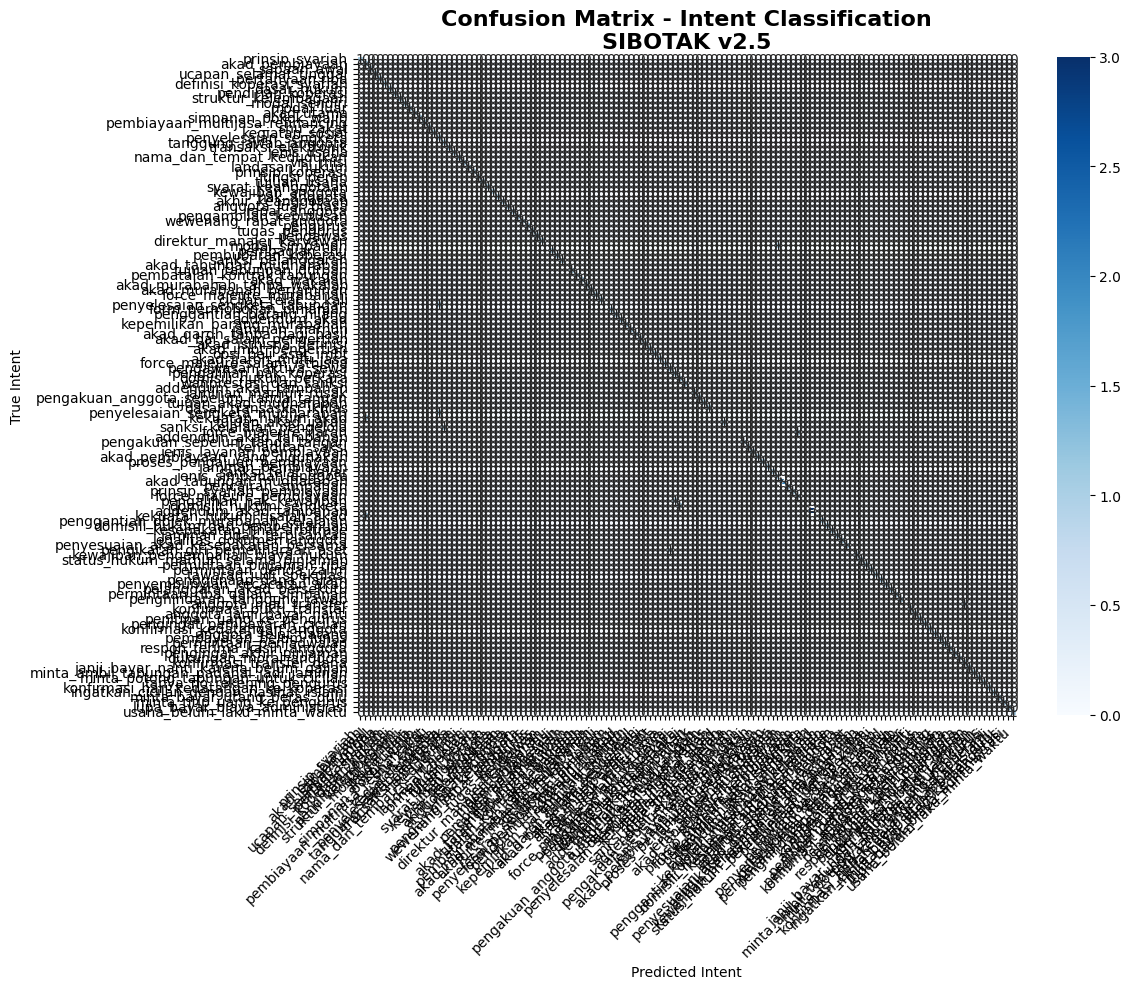

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=intent_names)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=intent_names, yticklabels=intent_names)
plt.title("Confusion Matrix - Intent Classification\nSIBOTAK v2.5", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

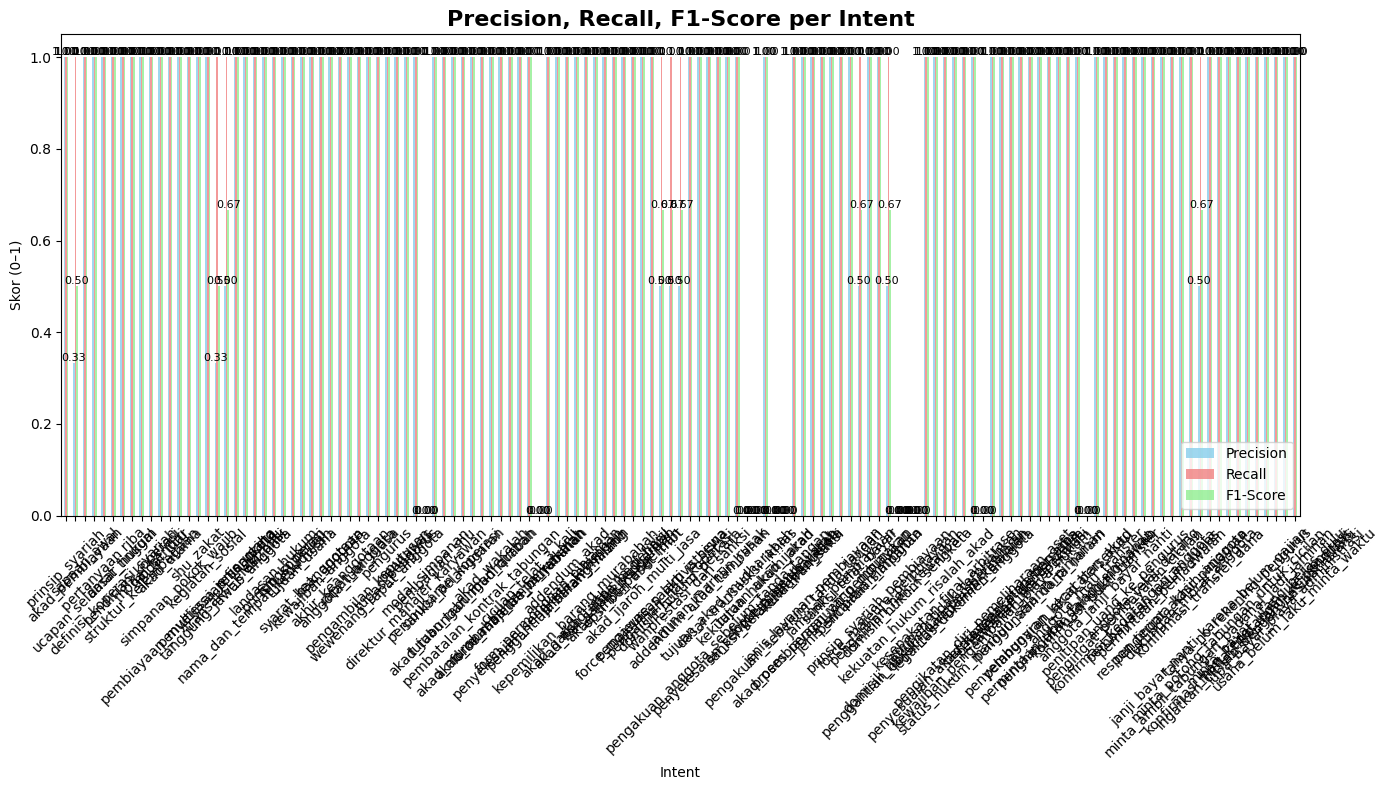

In [ ]:
# Classification Report
report = classification_report(y_test, y_pred, labels=intent_names, output_dict=True, zero_division=0)

# Konversi ke DataFrame
report_df = json.loads(json.dumps(report))
report_df = {k: v for k, v in report_df.items() if k in intent_names}  # Hanya intent
report_df = {
    'Intent': list(report_df.keys()),
    'Precision': [report_df[k]['precision'] for k in report_df.keys()],
    'Recall': [report_df[k]['recall'] for k in report_df.keys()],
    'F1-Score': [report_df[k]['f1-score'] for k in report_df.keys()]
}

import pandas as pd
report_df = pd.DataFrame(report_df)

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
report_df.set_index('Intent').plot(kind='bar', ax=ax, alpha=0.8, color=['skyblue', 'lightcoral', 'lightgreen'])
ax.set_title("Precision, Recall, F1-Score per Intent", fontsize=16, fontweight='bold')
ax.set_ylabel("Skor (0–1)")
ax.set_xlabel("Intent")
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', size=8)
plt.tight_layout()
plt.show()

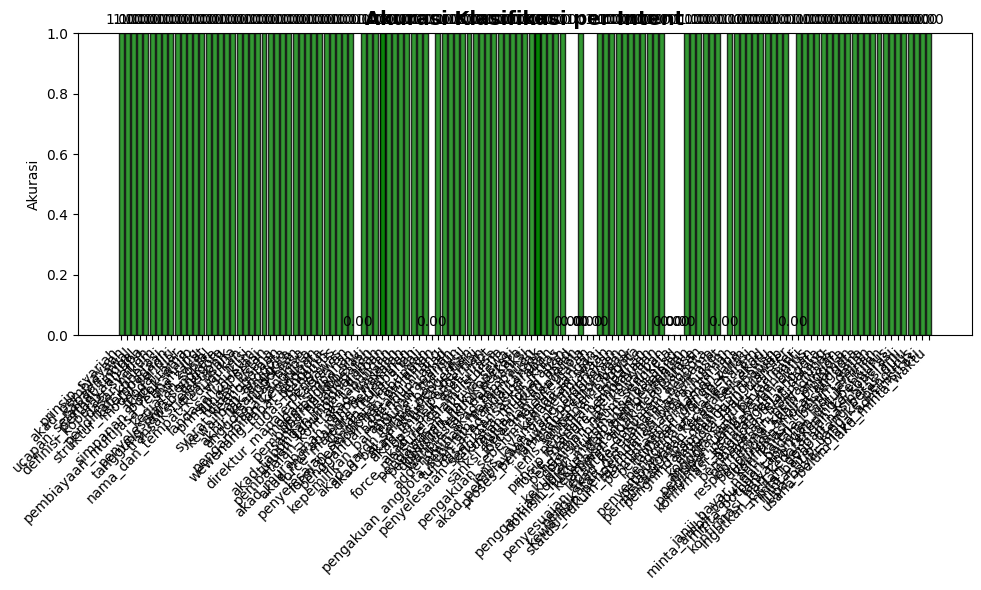

In [ ]:
# Hitung akurasi per intent
from collections import defaultdict

correct = defaultdict(int)
total = defaultdict(int)

for true, pred in zip(y_test, y_pred):
    total[true] += 1
    if true == pred:
        correct[true] += 1

accuracy_per_intent = {intent: correct[intent]/total[intent] for intent in intent_names}

# Plot
acc_values = [accuracy_per_intent.get(intent, 0) for intent in intent_names]
colors = ['red' if acc < 0.7 else 'orange' if acc < 0.9 else 'green' for acc in acc_values]

plt.figure(figsize=(10, 6))
bars = plt.bar(intent_names, acc_values, color=colors, edgecolor='black', alpha=0.8)
plt.title("Akurasi Klasifikasi per Intent", fontsize=14, fontweight='bold')
plt.ylabel("Akurasi")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

# Tambahkan label angka
for bar, acc in zip(bars, acc_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

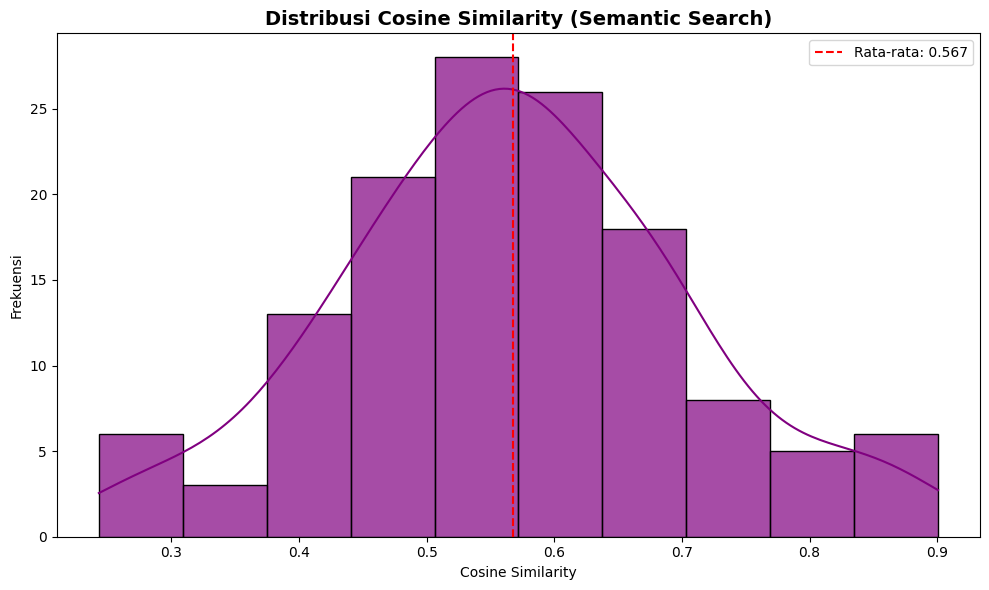

Rata-rata Cosine Similarity: 0.567
Rentang: 0.243 – 0.901


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Hitung similarity antara input uji dan embedding hasil
X_test_emb = model.encode(test_questions)
X_pred_emb = clf.predict(X_test)  # Kita ambil embedding dari pertanyaan terdekat

# Dapatkan embedding dari FAQ yang sesuai dengan prediksi
X_pred_closest = []
for pred_intent in y_pred:
    for item in faq_data:
        if item['intent'] == pred_intent:
            X_pred_closest.append(model.encode([item['question'].lower()])[0])
            break

X_pred_closest = np.array(X_pred_closest)

# Hitung cosine similarity
similarities = cosine_similarity(X_test_emb, X_pred_closest).diagonal()

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(similarities, bins=10, kde=True, color='purple', alpha=0.7)
plt.axvline(np.mean(similarities), color='red', linestyle='--', label=f'Rata-rata: {np.mean(similarities):.3f}')
plt.title("Distribusi Cosine Similarity (Semantic Search)", fontsize=14, fontweight='bold')
plt.xlabel("Cosine Similarity")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rata-rata Cosine Similarity: {np.mean(similarities):.3f}")
print(f"Rentang: {similarities.min():.3f} – {similarities.max():.3f}")

In [ ]:
# Ringkasan akhir
overall_accuracy = (np.array(y_test) == np.array(y_pred)).mean()
avg_similarity = np.mean(similarities)

summary = f"""
RINGKASAN KINERJA MODEL SIBOTAK

• Total Intent: {len(intent_names)}
• Data Uji: {len(y_test)} pertanyaan
• Akurasi Keseluruhan: {overall_accuracy:.2%}
• Rata-rata Cosine Similarity: {avg_similarity:.3f}
• Intent Terbaik: {max(accuracy_per_intent, key=accuracy_per_intent.get)} ({accuracy_per_intent[max(accuracy_per_intent, key=accuracy_per_intent.get)]:.2%})
• Intent Tertinggal: {min(accuracy_per_intent, key=accuracy_per_intent.get)} ({accuracy_per_intent[min(accuracy_per_intent, key=accuracy_per_intent.get)]:.2%})


"""

print(summary)


RINGKASAN KINERJA MODEL SIBOTAK

• Total Intent: 134
• Data Uji: 134 pertanyaan
• Akurasi Keseluruhan: 91.79%
• Rata-rata Cosine Similarity: 0.567
• Intent Terbaik: prinsip_syariah (100.00%)
• Intent Tertinggal: modal_simpanan (0.00%)





In [ ]:
import json
import pandas as pd
from datetime import datetime

def load_feedback():
    """
    Baca feedback.jsonl dan konversi ke list of dicts
    """
    feedbacks = []
    try:
        with open("feedback.jsonl", "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    feedbacks.append(json.loads(line))
    except FileNotFoundError:
        print("File feedback.jsonl tidak ditemukan.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error membaca feedback: {e}")
        return pd.DataFrame()

    df = pd.DataFrame(feedbacks)
    print(f"Berhasil muat {len(df)} feedback")
    print(f"{len(df[df['is_helpful'] == False])} feedback negatif ditemukan")
    return df

# Muat data
df_feedback = load_feedback()

if df_feedback.empty:
    print("Tidak ada data feedback untuk dievaluasi.")
else:
    # Tampilkan contoh
    print("\n 3 Contoh Feedback Negatif:")
    negatif = df_feedback[df_feedback['is_helpful'] == False]
    print(negatif[['user_query', 'intent', 'response']][:3])

File feedback.jsonl tidak ditemukan.
Tidak ada data feedback untuk dievaluasi.


In [ ]:
# Pisahkan feedback positif & negatif
total = len(df_feedback)
helpful = len(df_feedback[df_feedback['is_helpful']])
not_helpful = total - helpful

# Hitung tingkat kepuasan
satisfaction_rate = (helpful / total) * 100 if total > 0 else 0

print(f"""
METRIK KINERJA BERDASARKAN FEEDBACK NYATA
──────────────────────────────────────
🔹 Total Interaksi: {total}
🔹 Respons Membantu: {helpful} 👍
🔹 Respons Tidak Membantu: {not_helpful} 👎
🔹 Tingkat Kepuasan: {satisfaction_rate:.1f}%
──────────────────────────────────────
""")

KeyError: 'is_helpful'

File feedback.jsonl tidak ditemukan.
Tidak ada data feedback untuk dievaluasi.


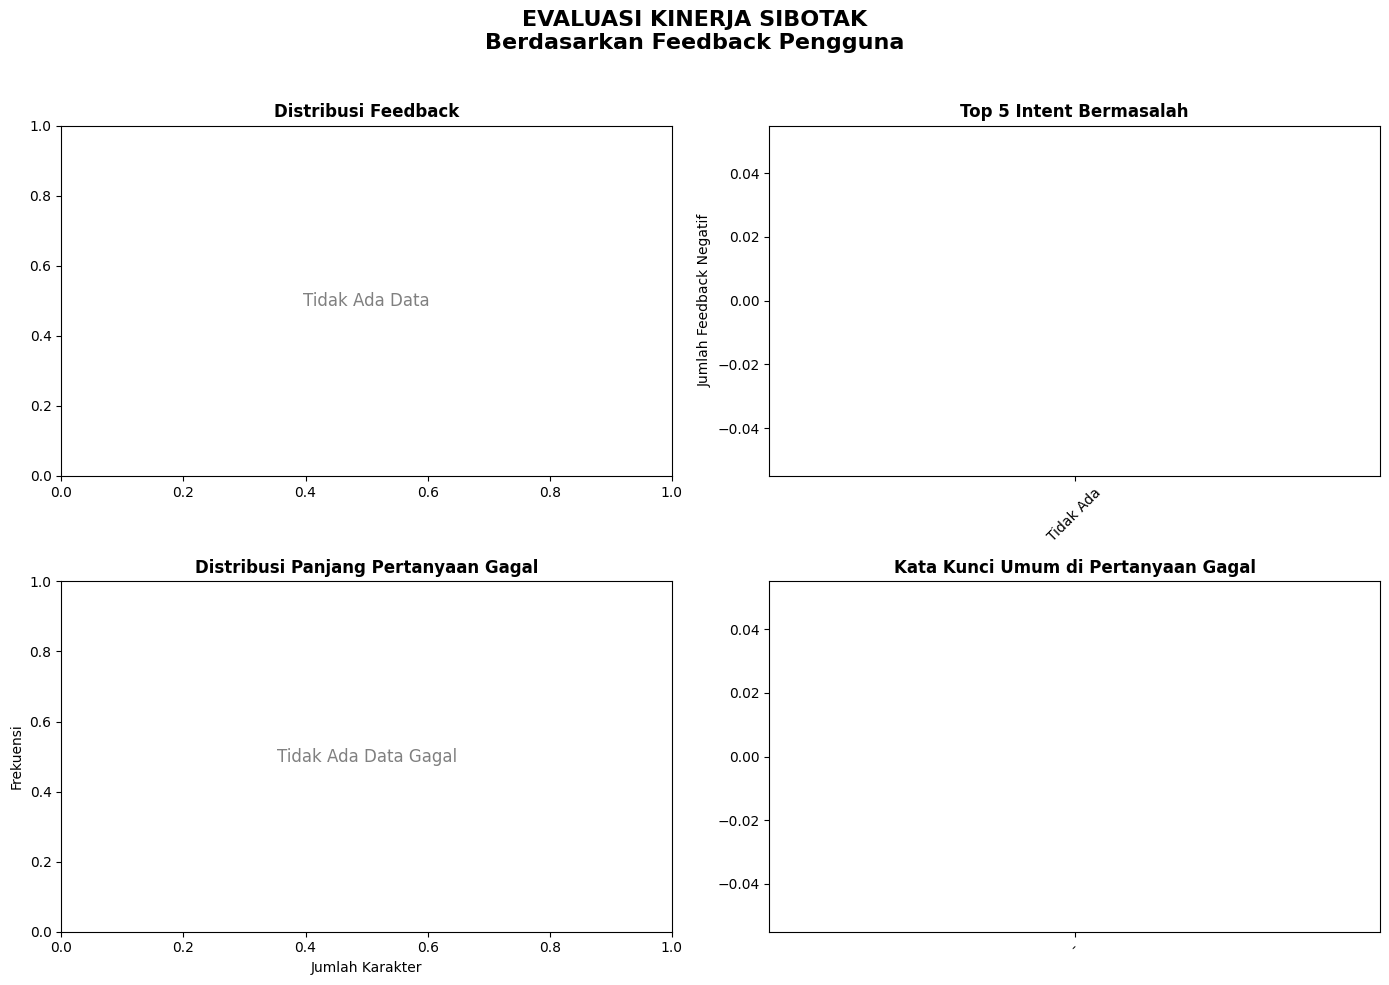

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime

# --- 1. Muat feedback.jsonl ---
def load_feedback():
    feedbacks = []
    try:
        with open("feedback.jsonl.backup_0820", "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    feedbacks.append(json.loads(line))
    except FileNotFoundError:
        print("File feedback.jsonl tidak ditemukan.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error membaca feedback: {e}")
        return pd.DataFrame()

    df = pd.DataFrame(feedbacks)
    print(f"Berhasil muat {len(df)} feedback")
    return df

df_feedback = load_feedback()

# --- Inisialisasi variabel default ---
negatif = pd.DataFrame()
top_failed_intent = []
word_freq = []

# --- Jika ada data, proses ---
if not df_feedback.empty:
    # Pisahkan feedback negatif
    negatif = df_feedback[df_feedback['is_helpful'] == False].copy()
    print(f"Ditemukan {len(negatif)} feedback tidak membantu")

    # Hitung intent yang bermasalah
    intent_failure = Counter(negatif['intent'])
    top_failed_intent = intent_failure.most_common(5)

    # Ekstrak kata kunci dari pertanyaan gagal
    common_words = []
    for query in negatif['user_query']:
        words = [w.lower().strip('.,?!"') for w in query.split() if len(w) > 3]
        common_words.extend(words)

    # PASTIKAN word_freq SELALU DIDEFINISIKAN
    word_freq = Counter(common_words).most_common(10)
else:
    print("Tidak ada data feedback untuk dievaluasi.")

# --- Visualisasi ---
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EVALUASI KINERJA SIBOTAK\nBerdasarkan Feedback Pengguna", fontsize=16, fontweight='bold')

# -----------------------------------------
# GRAFIK 1: Pie Chart - Feedback Positif vs Negatif
# -----------------------------------------
if not df_feedback.empty:
    helpful = len(df_feedback[df_feedback['is_helpful']])
    not_helpful = len(df_feedback[~df_feedback['is_helpful']])
    labels = ['Membantu', 'Tidak Membantu ']
    sizes = [helpful, not_helpful]
    colors = ['#4CAF50', '#F44336']
    axes[0, 0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
else:
    axes[0, 0].text(0.5, 0.5, 'Tidak Ada Data', ha='center', va='center', fontsize=12, color='gray')
axes[0, 0].set_title("Distribusi Feedback", fontsize=12, fontweight='bold')

# -----------------------------------------
# GRAFIK 2: Top 5 Intent Bermasalah
# -----------------------------------------
if top_failed_intent:
    intents, counts = zip(*top_failed_intent)
else:
    intents, counts = ['Tidak Ada'], [0]
axes[0, 1].bar(intents, counts, color='crimson', alpha=0.8)
axes[0, 1].set_title("Top 5 Intent Bermasalah", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Jumlah Feedback Negatif")
axes[0, 1].tick_params(axis='x', rotation=45)

# -----------------------------------------
# GRAFIK 3: Panjang Pertanyaan Gagal
# -----------------------------------------
if not negatif.empty:
    negatif['query_length'] = negatif['user_query'].str.len()
    axes[1, 0].hist(negatif['query_length'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(negatif['query_length'].mean(), color='red', linestyle='--', label=f'Rata-rata: {negatif["query_length"].mean():.0f}')
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, 'Tidak Ada Data Gagal', ha='center', va='center', fontsize=12, color='gray')
axes[1, 0].set_title("Distribusi Panjang Pertanyaan Gagal", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Jumlah Karakter")
axes[1, 0].set_ylabel("Frekuensi")

# -----------------------------------------
# GRAFIK 4: Kata Kunci Umum di Pertanyaan Gagal
# -----------------------------------------
if word_freq:
    words, freqs = zip(*word_freq[:6])  # Ambil 6 teratas
else:
    words, freqs = ['-', '-'], [0, 0]  # Placeholder
axes[1, 1].bar(words, freqs, color='orange', alpha=0.8)
axes[1, 1].set_title("Kata Kunci Umum di Pertanyaan Gagal", fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

# -----------------------------------------
# Tampilkan
# -----------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
from collections import Counter

# Ambil semua feedback negatif
negatif = df_feedback[df_feedback['is_helpful'] == False].copy()

# Tambahkan kolom panjang pertanyaan
negatif['query_length'] = negatif['user_query'].str.len()

# 1. Intent mana yang paling sering gagal?
intent_failure = Counter(negatif['intent'])
top_failed_intent = intent_failure.most_common(3)

print("Intent dengan Masalah Terbanyak:")
for intent, count in top_failed_intent:
    print(f"   • {intent}: {count} kali tidak membantu")

# 2. Apakah pertanyaan terlalu pendek/panjang?
print(f"\n📏 Statistik Panjang Pertanyaan Gagal:")
print(f"   • Rata-rata: {negatif['query_length'].mean():.0f} karakter")
print(f"   • Terpendek: {negatif['query_length'].min()} karakter")
print(f"   • Terpanjang: {negatif['query_length'].max()} karakter")

# 3. Kata kunci umum dalam pertanyaan gagal
common_words = []
for query in negatif['user_query']:
    words = [w.lower().strip('.,?!"') for w in query.split() if len(w) > 3]
    common_words.extend(words)

word_freq = Counter(common_words).most_common(10)
print(f"\nKata Kunci Umum di Pertanyaan Gagal:")
for word, freq in word_freq:
    print(f"   • '{word}': {freq}x")

KeyError: 'is_helpful'

In [ ]:
import time
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import json
import os

# --- 1. Muat data FAQ ---
with open("faq_data.json", "r", encoding="utf-8") as f:
    faq_data = json.load(f)

questions = []
for item in faq_data:
    questions.append(item['question'].lower())
    questions.extend([v.lower() for v in item.get('variations', [])])

print(f"Total pertanyaan untuk pengujian: {len(questions)}")

# --- 2. Muat model embedding ---
model = SentenceTransformer('indobenchmark/indobert-base-p2')
X = np.array(model.encode(questions), dtype=np.float32)
dimension = X.shape[1]

# --- 3. Buat dua jenis indeks: Flat (Brute-force) vs HNSW ---
# a. Index Flat (Sebelum HNSW) - Brute-force
index_flat = faiss.IndexFlatIP(dimension)  # Inner Product (cosine similarity)
index_flat.add(X)

# b. Index HNSW (Sesudah HNSW) - Approximate Search
index_hnsw = faiss.IndexHNSWFlat(dimension, 32)  # M=32 (parameter HNSW)
index_hnsw.add(X)

print(f"Indeks Flat dan HNSW telah dibuat.")

Total pertanyaan untuk pengujian: 797
Indeks Flat dan HNSW telah dibuat.


In [ ]:
def benchmark_search(index, query_embedding, k=1, name=""):
    times = []
    for _ in range(100):  # Uji 100 kali
        start = time.time()
        D, I = index.search(query_embedding, k)
        times.append(time.time() - start)
    avg_time = np.mean(times) * 1000  # dalam milidetik
    std_time = np.std(times) * 1000
    print(f"{name:15} | Rata-rata: {avg_time:.4f} ms | Std: {std_time:.4f} ms")
    return avg_time, std_time

# --- 4. Uji dengan beberapa pertanyaan ---
test_queries = [
    "cara ajukan pembiayaan?",
    "bedanya dengan bank konvensional?",
    "produk pembiayaan apa saja?",
    "apa itu akad murabahah?",
    "pinjaman jenisnya apa aja sih"
]

# Encode pertanyaan uji
X_test = model.encode(test_queries)
X_test = np.array(X_test, dtype=np.float32)

print("\nMULAI PENGUJIAN KECEPATAN RESPON\n")
print(f"{'Model':<15} | {'Rata-rata (ms)':<14} | {'Std (ms)'}")
print("-" * 50)

# Uji semua pertanyaan
results_flat = []
results_hnsw = []

for i, q_emb in enumerate(X_test):
    q_emb = np.array([q_emb])

    print(f"\nUji {i+1}: '{test_queries[i]}'")
    avg_flat, std_flat = benchmark_search(index_flat, q_emb, name="Flat (Brute)")
    avg_hnsw, std_hnsw = benchmark_search(index_hnsw, q_emb, name="HNSW (ANN)")

    results_flat.append(avg_flat)
    results_hnsw.append(avg_hnsw)


MULAI PENGUJIAN KECEPATAN RESPON

Model           | Rata-rata (ms) | Std (ms)
--------------------------------------------------

Uji 1: 'cara ajukan pembiayaan?'
Flat (Brute)    | Rata-rata: 0.3194 ms | Std: 0.7429 ms
HNSW (ANN)      | Rata-rata: 0.0578 ms | Std: 0.0165 ms

Uji 2: 'bedanya dengan bank konvensional?'
Flat (Brute)    | Rata-rata: 0.3014 ms | Std: 0.5092 ms
HNSW (ANN)      | Rata-rata: 0.1519 ms | Std: 0.4052 ms

Uji 3: 'produk pembiayaan apa saja?'
Flat (Brute)    | Rata-rata: 0.3570 ms | Std: 0.8173 ms
HNSW (ANN)      | Rata-rata: 0.0538 ms | Std: 0.0156 ms

Uji 4: 'apa itu akad murabahah?'
Flat (Brute)    | Rata-rata: 0.2032 ms | Std: 0.1966 ms
HNSW (ANN)      | Rata-rata: 0.0434 ms | Std: 0.0118 ms

Uji 5: 'pinjaman jenisnya apa aja sih'
Flat (Brute)    | Rata-rata: 0.2128 ms | Std: 0.2145 ms
HNSW (ANN)      | Rata-rata: 0.0624 ms | Std: 0.0166 ms


In [ ]:
import matplotlib.pyplot as plt

# Rata-rata dari semua uji
overall_flat = np.mean(results_flat)
overall_hnsw = np.mean(results_hnsw)

labels = ['Flat (Brute-Force)', 'HNSW (ANN)']
values = [overall_flat, overall_hnsw]
colors = ['salmon', 'skyblue']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors, edgecolor='black', alpha=0.8)
plt.title("Perbandingan Kecepatan Respons Chatbot\nSebelum vs Sesudah HNSW", fontsize=14, fontweight='bold')
plt.ylabel("Waktu Respons Rata-rata (ms)")
plt.grid(axis='y', alpha=0.3)

# Tambahkan angka di atas bar
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{value:.3f} ms', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nRingkasan:")
print(f"   • HNSW **{overall_flat/overall_hnsw:.1f}x lebih cepat** daripada Flat")
print(f"   • Rata-rata waktu HNSW: **{overall_hnsw:.3f} ms** → sangat responsif")

NameError: name 'np' is not defined

In [ ]:
# Evaluasi SIBOTAK: Precision@k, Recall@k, MAP, dan Cosine Similarity
import json
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

# --- 1. Muat data FAQ ---
with open("faq_data.json", "r", encoding="utf-8") as f:
    faq_data = json.load(f)

# Kumpulkan semua pertanyaan + variasi sebagai data latih
all_questions = []
all_intents = []

for item in faq_data:
    q = item["question"].lower()
    all_questions.append(q)
    all_intents.append(item["intent"])
    for var in item.get("variations", []):
        all_questions.append(var.lower())
        all_intents.append(item["intent"])

print(f"Total data latih: {len(all_questions)} pertanyaan, {len(faq_data)} intent")

# --- 2. Siapkan data uji (simulasi hold-out: 1 variasi per intent sebagai uji) ---
test_questions = []
test_intents = []

for item in faq_data:
    variations = item.get("variations", [])
    if variations:
        test_questions.append(variations[0].lower())
        test_intents.append(item["intent"])
    else:
        test_questions.append(item["question"].lower())
        test_intents.append(item["intent"])

print(f"Total data uji: {len(test_questions)}")

# --- 3. Encode dengan IndoBERT ---
model = SentenceTransformer('indobenchmark/indobert-base-p2')
X_train = model.encode(all_questions)
X_test = model.encode(test_questions)

X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

# Normalisasi untuk cosine similarity (FAISS Inner Product)
faiss.normalize_L2(X_train)
faiss.normalize_L2(X_test)

# --- 4. Bangun indeks FAISS (Flat untuk akurasi penuh) ---
dim = X_train.shape[1]
index = faiss.IndexFlatIP(dim)  # Inner Product = Cosine setelah normalisasi
index.add(X_train)

# --- 5. Fungsi evaluasi top-k ---
def evaluate_at_k(k=5):
    precisions = []
    recalls = []
    average_precisions = []
    cosine_sims = []

    for i, (query_emb, true_intent) in enumerate(zip(X_test, test_intents)):
        # Cari top-k
        D, I = index.search(query_emb.reshape(1, -1), k)
        retrieved_intents = [all_intents[idx] for idx in I[0]]



        # Relevansi: 1 jika intent cocok, 0 jika tidak
        relevances = [1 if intent == true_intent else 0 for intent in retrieved_intents]

        # Precision@k & Recall@k (karena hanya 1 label benar)
        precision_k = sum(relevances) / k
        recall_k = sum(relevances) / 1  # hanya 1 dokumen relevan
        precisions.append(precision_k)
        recalls.append(recall_k)

        # Hitung Average Precision (AP)
        ap = 0.0
        relevant_count = 0
        for j, rel in enumerate(relevances):
            if rel == 1:
                relevant_count += 1
                precision_at_j = relevant_count / (j + 1)
                ap += precision_at_j
        ap = ap / 1  # hanya 1 dokumen relevan
        average_precisions.append(ap)

    return {
        "Precision@k": np.mean(precisions),
        "Recall@k": np.mean(recalls),
        "MAP": np.mean(average_precisions),
    }

# --- 6. Jalankan evaluasi untuk k = 1, 3, 5 ---
for k in [1, 3, 5]:
    print(f"\nEvaluasi untuk k = {k}")
    metrics = evaluate_at_k(k=k)
    for key, val in metrics.items():
        if "Cosine" in key:
            print(f"  {key}: {val:.3f}")
        else:
            print(f"  {key}: {val:.4f}")

Total data latih: 797 pertanyaan, 134 intent
Total data uji: 134

Evaluasi untuk k = 1
  Precision@k: 0.9552
  Recall@k: 0.9552
  MAP: 0.9552

Evaluasi untuk k = 3
  Precision@k: 0.4204
  Recall@k: 1.2612
  MAP: 1.2239

Evaluasi untuk k = 5
  Precision@k: 0.2836
  Recall@k: 1.4179
  MAP: 1.3129
